## Stage 0: Scaffold

Repository layout, pinned requirements, README skeleton, and smoke tests.

## Stage 1a: History (SPY, VIX, IRX)

Download and freeze SPY, ^VIX, and ^IRX daily closes with a manifest.

## Stage 1b: Chain collection

Run the chain collector on 3 to 5 market days and freeze the snapshot.

## Stage 2a: Black-Scholes pricing and Greeks

Implement Black-76 pricing and spot Greeks; verify against DESIGN.md acceptance values.

## Stage 5a: Hedging engine

Implement the delta-hedging simulation and verify on synthetic GBM paths.

## Stage 5b: Real-data hedging study

Run the hedging study on real SPY paths; produce Figures 6 to 8 and Table 4.

The study delta-hedges a 30-day at-the-money call bought at the VIX on every trading day, following DESIGN.md section 3. It reads only the frozen history, so it reruns without a download. P&L and predictors are fractions of the premium carried to expiry (C0·G0), shown in percent.

In [1]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FixedLocator, NullLocator, ScalarFormatter

from volsurf import hedging as hg
from volsurf.black_scholes import bs_vega
from volsurf.data import load_history

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "pyproject.toml").exists())
FIGURES = ROOT / "figures"

H_VALUES = [1, 2, 3, 5, 7, 10, 21]  # rebalance interval in trading days
C_BP = [0, 1, 5, 25, 100]  # cost in bp of notional traded
PREDICTORS = ["P_gap", "P_price", "P_path", "P_step"]
BLOCK, N_RESAMPLES, SEED_BOOT = 42, 2000, 20260930  # moving block bootstrap
BLOCKS_SENSITIVITY = (84, 126)  # longer blocks for the headline intervals
N_PATHS, SEED_GBM = 100, 20261001  # GBM paths per real window; windows of n steps use seed [SEED_GBM, n]
SEEDS_TEXTBOOK = [(20261100 + k, 20261200 + k) for k in range(40)]  # section 3 set, 40 seed pairs
APRIL_2025 = ("2025-04-03", "2025-04-09")
STRIDE = 22  # non-overlapping subsamples: windows k, k + 22, k + 44, ... for each offset k

# Chart style: recessive grid and axes, ink for text, series colours for marks only.
INK, INK_2, MUTED, GRID, AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
COST_COLOURS = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]  # one blue, light to dark with cost
COST_MARKERS = ["o", "s", "^", "D", "v"]
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": AXIS, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "text.color": INK, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "font.size": 9, "axes.titlesize": 10, "figure.titlesize": 11, "legend.frameon": False,
    "lines.linewidth": 2, "lines.markersize": 5,
})


def save(fig, name):
    """Save a figure to figures/ at 200 dpi and print its repository-relative path."""
    path = FIGURES / name
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Saved {path.relative_to(ROOT).as_posix()}")


def predictors(res, rows=slice(None)):
    """The three predictors of a HedgeResult, optionally restricted to some windows."""
    return {name: getattr(res, name.lower())[rows] for name in PREDICTORS}


history = load_history()
dates = history.index
S, r = history["spy"].to_numpy(), history["r"].to_numpy()
win = hg.study_windows(history)
steps = win.ends - win.starts
start_dates = dates[win.starts]
print(f"History: {dates[0].date()} to {dates[-1].date()}, {dates.size} closes")
print(
    f"Windows: {win.starts.size}, starting {start_dates[0].date()} to {start_dates[-1].date()}; "
    f"{steps.min()} to {steps.max()} trading-day steps; T0 from {win.T0.min() * 365:.0f} "
    f"to {win.T0.max() * 365:.0f} calendar days"
)

History: 2021-06-01 to 2026-09-29, 1339 closes
Windows: 1232, starting 2021-10-01 to 2026-08-28; 17 to 22 trading-day steps; T0 from 27 to 30 calendar days


In [2]:
results = {
    (h, c): hg.simulate_windows(S, win.t, r, win.starts, win.ends, win.sigma_i, win.K, h, c * 1e-4)
    for h in H_VALUES
    for c in C_BP
}
base = results[(1, 0)]  # daily hedging, no costs
n_by_h = {h: results[(h, 0)].n_intervals for h in H_VALUES}
print("Hedge intervals N per window: mean (min to max)")
for h in H_VALUES:
    print(f"  h = {h:>2}: {n_by_h[h].mean():5.2f} ({n_by_h[h].min()} to {n_by_h[h].max()})")

Hedge intervals N per window: mean (min to max)
  h =  1: 20.58 (17 to 22)
  h =  2: 10.55 (9 to 11)
  h =  3:  7.17 (6 to 8)
  h =  5:  4.58 (4 to 5)
  h =  7:  3.20 (3 to 4)
  h = 10:  2.58 (2 to 3)
  h = 21:  1.20 (1 to 2)


## Figure 7: implied against realised volatility
VIX at each window start against the realised volatility of that window, sigma_r = √(RV/T0), where RV sums squared daily log returns. The share of windows whose implied total variance exceeds the realised one does not depend on h or c, so it is reported once.

Share of windows with sigma_i^2*T0 > RV: 84.3% of 1232
Mean sigma_i (VIX): 19.18%; mean realised vol sigma_r: 15.78%
Mean total variance over a window: implied 0.00319, realised 0.00246


Saved figures/fig7_vix_vs_realised_vol.png


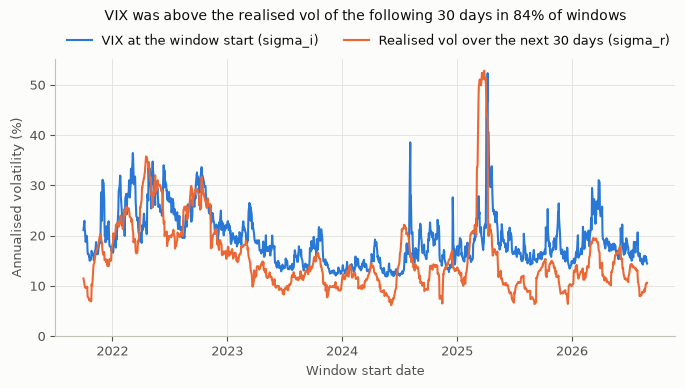

In [3]:
implied_var, rv = win.sigma_i**2 * win.T0, base.rv
sigma_r = np.sqrt(rv / win.T0)
share_implied_above = np.mean(implied_var > rv)
print(f"Share of windows with sigma_i^2*T0 > RV: {share_implied_above:.1%} of {rv.size}")
print(f"Mean sigma_i (VIX): {win.sigma_i.mean():.2%}; mean realised vol sigma_r: {sigma_r.mean():.2%}")
print(f"Mean total variance over a window: implied {implied_var.mean():.5f}, realised {rv.mean():.5f}")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(start_dates, 100 * win.sigma_i, color=BLUE, lw=1.5, label="VIX at the window start (sigma_i)")
ax.plot(start_dates, 100 * sigma_r, color=ORANGE, lw=1.5, label="Realised vol over the next 30 days (sigma_r)")
ax.set_xlabel("Window start date")
ax.set_ylabel("Annualised volatility (%)")
ax.set_ylim(bottom=0)
ax.set_title(
    f"VIX was above the realised vol of the following 30 days in {share_implied_above:.0%} of windows",
    pad=28,
)
ax.legend(loc="lower left", bbox_to_anchor=(0.0, 1.0), ncol=2)
save(fig, "fig7_vix_vs_realised_vol.png")
plt.show()

## Table 4b: the R² ladder at c = 0
The ladder has four rungs: P_gap (the vol gap), P_price (the option repriced at the realised vol minus its premium, the exact expected P&L under GBM, so the step from P_gap isolates P_gap's functional form), P_path (the path's own gamma) and P_step (the timing of each move against gamma). R²_45 is measured about the 45 degree line, the OLS R² next to it ignores intercept and slope, and the slope comes from OLS of P&L on each predictor. Intervals are 95% moving block bootstrap percentiles over windows in start-date order. The GBM benchmark hedges 100 GBM paths on each real window's calendar and rates, with sigma_true set to that window's realised vol and sigma_i to its VIX, and pools every path. The April 2025 rows drop every window with a close from 2025-04-03 to 2025-04-09 and resample the remaining sequence; the benchmark is shown with and without the paths of those windows, so each real sample has a like-for-like benchmark.

In [4]:
april = hg.windows_containing(dates, win.starts, win.ends, *APRIL_2025)
keep = ~april
boot_full = hg.block_bootstrap_indices(win.starts.size, BLOCK, N_RESAMPLES, SEED_BOOT)
boot_keep = hg.block_bootstrap_indices(int(keep.sum()), BLOCK, N_RESAMPLES, SEED_BOOT)
print(
    f"April 2025 exclusion: {april.sum()} windows removed (starts {start_dates[april][0].date()} "
    f"to {start_dates[april][-1].date()}), {keep.sum()} kept"
)

gbm_benchmark = {
    h: hg.simulate_gbm_windows(win.t, r, win.starts, win.ends, sigma_r, win.sigma_i, h, 0.0, N_PATHS, SEED_GBM)
    for h in H_VALUES
}
ladders = {}
for h in H_VALUES:
    res, bench = results[(h, 0)], gbm_benchmark[h]
    ladders[("Full sample", h)] = hg.r2_ladder(res.pnl, predictors(res), boot_full)
    ladders[("GBM benchmark", h)] = hg.r2_ladder(
        bench.pnl.ravel(), {k: v.ravel() for k, v in predictors(bench).items()}
    )
    ladders[("Excluding April 2025", h)] = hg.r2_ladder(res.pnl[keep], predictors(res, keep), boot_keep)
    ladders[("GBM benchmark excluding April 2025", h)] = hg.r2_ladder(
        bench.pnl[keep].ravel(), {k: v[keep].ravel() for k, v in predictors(bench).items()}
    )
table_4b = pd.concat(ladders, names=["sample", "h", "predictor"])
with pd.option_context("display.max_rows", 200, "display.float_format", "{:.3f}".format):
    display(table_4b)

April 2025 exclusion: 27 windows removed (starts 2025-03-04 to 2025-04-09), 1205 kept


n  r2_45  r2_lo  r2_hi  \
sample                             h  predictor                                
Full sample                        1  P_gap        1232 -0.199 -1.124  0.643   
                                      P_price      1232  0.584  0.496  0.688   
                                      P_path       1232  0.671  0.472  0.847   
                                      P_step       1232  0.941  0.919  0.956   
GBM benchmark                      1  P_gap      123200  0.572    NaN    NaN   
                                      P_price    123200  0.808    NaN    NaN   
                                      P_path     123200  0.923    NaN    NaN   
                                      P_step     123200  0.963    NaN    NaN   
Excluding April 2025               1  P_gap        1205  0.592  0.512  0.665   
                                      P_price      1205  0.606  0.501  0.696   
                                      P_path       1205  0.830  0.788  0.858   
                                      P_step       1205  0.942  0.914  0.959   
GBM benchmark excluding April 2025 1  P_gap      120500  0.744    NaN    NaN   
                                      P_price    120500  0.808    NaN    NaN   
                                      P_path     120500  0.921    NaN    NaN   
                                      P_step     120500  0.971    NaN    NaN   
Full sample                        2  P_gap        1232 -0.066 -0.701  0.481   
                                      P_price      1232  0.459  0.324  0.547   
                                      P_path       1232  0.462  0.254  0.647   
                                      P_step       1232  0.800  0.629  0.931   
GBM benchmark                      2  P_gap      123200  0.484    NaN    NaN   
                                      P_price    123200  0.696    NaN    NaN   
                                      P_path     123200  0.768    NaN    NaN   
                                      P_step     123200  0.931    NaN    NaN   
Excluding April 2025               2  P_gap        1205  0.413  0.294  0.500   
                                      P_price      1205  0.410  0.266  0.527   
                                      P_path       1205  0.597  0.493  0.668   
                                      P_step       1205  0.905  0.858  0.936   
GBM benchmark excluding April 2025 2  P_gap      120500  0.605    NaN    NaN   
                                      P_price    120500  0.657    NaN    NaN   
                                      P_path     120500  0.744    NaN    NaN   
                                      P_step     120500  0.948    NaN    NaN   
Full sample                        3  P_gap        1232 -0.081 -0.668  0.395   
                                      P_price      1232  0.369  0.226  0.465   
                                      P_path       1232  0.404  0.258  0.536   
                                      P_step       1232  0.853  0.788  0.912   
GBM benchmark                      3  P_gap      123200  0.433    NaN    NaN   
                                      P_price    123200  0.619    NaN    NaN   
                                      P_path     123200  0.656    NaN    NaN   
                                      P_step     123200  0.904    NaN    NaN   
Excluding April 2025               3  P_gap        1205  0.325  0.203  0.417   
                                      P_price      1205  0.318  0.174  0.437   
                                      P_path       1205  0.479  0.372  0.554   
                                      P_step       1205  0.889  0.846  0.917   
GBM benchmark excluding April 2025 3  P_gap      120500  0.517    NaN    NaN   
                                      P_price    120500  0.559    NaN    NaN   
                                      P_path     120500  0.629    NaN    NaN   
                                      P_step     120500  0.924    NaN    NaN   
Full sample                        5  P_gap        123

## Table 4b: block-length sensitivity
Vol regimes last far longer than 42 trading days, so a block of 42 windows can cut through one and understate the uncertainty. The headline intervals (daily hedging, no costs, full and April-excluded samples) are therefore recomputed with blocks of 84 and 126 windows next to 42, each block length on its own 2,000 resamples with seed 20260930. Longer blocks keep more of a regime inside one block, at the cost of fewer blocks per resample.

In [5]:
blocks = (BLOCK, *BLOCKS_SENSITIVITY)
samples_1 = {"Full sample": np.ones(win.starts.size, dtype=bool), "Excluding April 2025": keep}
boot_blocks = {
    (sample, block): hg.block_bootstrap_indices(int(rows.sum()), block, N_RESAMPLES, SEED_BOOT)
    for sample, rows in samples_1.items()
    for block in blocks
}
# Block 42 reproduces the Table 4b resamples exactly.
assert np.array_equal(boot_blocks[("Full sample", BLOCK)], boot_full)
assert np.array_equal(boot_blocks[("Excluding April 2025", BLOCK)], boot_keep)
for sample, rows in samples_1.items():
    print(f"{sample}: {rows.sum()} windows; blocks per resample "
          + ", ".join(f"{-(-int(rows.sum()) // block)} at block {block}" for block in blocks))

res_1 = results[(1, 0)]
table_4b_blocks = pd.concat(
    {
        (sample, block): hg.r2_ladder(res_1.pnl[rows], predictors(res_1, rows), boot_blocks[(sample, block)])
        for sample, rows in samples_1.items()
        for block in blocks
    },
    names=["sample", "block", "predictor"],
)[["n", "r2_45", "r2_lo", "r2_hi", "beta", "beta_lo", "beta_hi"]]
with pd.option_context("display.max_rows", 100, "display.float_format", "{:.3f}".format):
    display(table_4b_blocks)

Full sample: 1232 windows; blocks per resample 30 at block 42, 15 at block 84, 10 at block 126
Excluding April 2025: 1205 windows; blocks per resample 29 at block 42, 15 at block 84, 10 at block 126


n  r2_45  r2_lo  r2_hi  beta  \
sample               block predictor                                    
Full sample          42    P_gap      1232 -0.199 -1.124  0.643 0.473   
                           P_price    1232  0.584  0.496  0.688 0.691   
                           P_path     1232  0.671  0.472  0.847 0.715   
                           P_step     1232  0.941  0.919  0.956 0.961   
                     84    P_gap      1232 -0.199 -1.142  0.635 0.473   
                           P_price    1232  0.584  0.500  0.672 0.691   
                           P_path     1232  0.671  0.470  0.840 0.715   
                           P_step     1232  0.941  0.919  0.954 0.961   
                     126   P_gap      1232 -0.199 -1.144  0.626 0.473   
                           P_price    1232  0.584  0.504  0.672 0.691   
                           P_path     1232  0.671  0.475  0.840 0.715   
                           P_step     1232  0.941  0.922  0.952 0.961   
Excluding April 2025 42    P_gap      1205  0.592  0.512  0.665 0.818   
                           P_price    1205  0.606  0.501  0.696 0.773   
                           P_path     1205  0.830  0.788  0.858 0.949   
                           P_step     1205  0.942  0.914  0.959 1.002   
                     84    P_gap      1205  0.592  0.504  0.660 0.818   
                           P_price    1205  0.606  0.481  0.687 0.773   
                           P_path     1205  0.830  0.786  0.850 0.949   
                           P_step     1205  0.942  0.917  0.957 1.002   
                     126   P_gap      1205  0.592  0.491  0.653 0.818   
                           P_price    1205  0.606  0.480  0.690 0.773   
                           P_path     1205  0.830  0.780  0.849 0.949   
                           P_step     1205  0.942  0.918  0.957 1.002   

                                      beta_lo  beta_hi  
sample               block predictor                    
Full sample          42    P_gap        0.391    0.942  
                           P_price      0.630    0.845  
                           P_path       0.610    1.018  
                           P_step       0.914    1.024  
                     84    P_gap        0.390    0.926  
                           P_price      0.631    0.831  
                           P_path       0.607    1.013  
                           P_step       0.915    1.018  
                     126   P_gap        0.391    0.915  
                           P_price      0.632    0.829  
                           P_path       0.608    1.018  
                           P_step       0.916    1.016  
Excluding April 2025 42    P_gap        0.716    1.010  
                           P_price      0.708    0.865  
                           P_path       0.863    1.044  
                           P_step       0.970    1.030  
                     84    P_gap        0.717    0.997  
                           P_price      0.711    0.854  
                           P_path       0.866    1.036  
                           P_step       0.970    1.025  
                     126   P_gap        0.722    0.985  
                           P_price      0.716    0.847  
                           P_path       0.867    1.034  
                           P_step       0.971    1.024

## Table 4c: non-overlapping subsamples
Subsample k takes windows k, k + 22, k + 44, and so on, for each offset k from 0 to 21, so the 22 subsamples between them hold every window once. No window is longer than the stride, so windows 22 apart share no daily return, which stride_subsamples checks. The table gives the point estimates for offset 0 and the median and range across all 22. The subsamples interleave the same months and the same vol regimes, so the range shows how sensitive the estimates are to the alignment of the windows (the days they start on). It is not a sampling distribution and not a confidence interval.

In [6]:
subsamples = hg.stride_subsamples(win.starts, win.ends, STRIDE)  # raises if any two windows share a return
sizes = [sub.size for sub in subsamples]
covers_all = np.array_equal(np.sort(np.concatenate(subsamples)), np.arange(win.starts.size))
print(f"{len(subsamples)} subsamples at stride {STRIDE}, {min(sizes)} to {max(sizes)} windows each; "
      f"each window in exactly one: {covers_all}")
print(f"Longest window: {steps.max()} steps, no longer than the stride")
weekday_0 = pd.Series(start_dates[subsamples[0]].day_name()).value_counts()
print("Start weekdays of the offset-0 subsample: " + ", ".join(f"{d} {n}" for d, n in weekday_0.items()))
table_4c = pd.concat(
    {h: hg.stride_ladder(results[(h, 0)].pnl, predictors(results[(h, 0)]), subsamples) for h in H_VALUES},
    names=["h", "predictor"],
)
with pd.option_context("display.max_rows", 100, "display.float_format", "{:.3f}".format):
    display(table_4c)

22 subsamples at stride 22, 56 to 56 windows each; each window in exactly one: True
Longest window: 22 steps, no longer than the stride
Start weekdays of the offset-0 subsample: Friday 15, Wednesday 12, Tuesday 11, Monday 9, Thursday 9


n_offset0  r2_45_offset0  r2_45_median  r2_45_min  r2_45_max  \
h  predictor                                                                 
1  P_gap             56          0.382         0.277     -3.524      0.730   
   P_price           56          0.500         0.607     -0.023      0.790   
   P_path            56          0.528         0.659      0.185      0.883   
   P_step            56          0.883         0.946      0.845      0.981   
2  P_gap             56          0.156         0.042     -2.886      0.630   
   P_price           56          0.254         0.388     -0.140      0.710   
   P_path            56          0.334         0.378     -0.196      0.810   
   P_step            56          0.774         0.900     -0.676      0.964   
3  P_gap             56          0.012         0.065     -1.972      0.558   
   P_price           56          0.109         0.372     -0.133      0.593   
   P_path            56          0.143         0.429     -0.125      0.695   
   P_step            56          0.816         0.906      0.423      0.958   
5  P_gap             56          0.105        -0.581     -3.040      0.247   
   P_price           56          0.164         0.062     -0.718      0.384   
   P_path            56          0.220         0.128     -2.080      0.479   
   P_step            56          0.789         0.857      0.643      0.921   
7  P_gap             56          0.043         0.002     -1.538      0.320   
   P_price           56          0.080         0.181     -0.264      0.498   
   P_path            56          0.168         0.150     -0.552      0.546   
   P_step            56          0.600         0.854      0.600      0.884   
10 P_gap             56          0.137        -0.446     -1.302      0.450   
   P_price           56          0.161        -0.085     -0.391      0.499   
   P_path            56          0.227        -0.195     -0.833      0.514   
   P_step            56          0.744         0.817      0.744      0.880   
21 P_gap             56          0.117        -0.148     -0.691      0.229   
   P_price           56          0.119        -0.044     -0.325      0.193   
   P_path            56          0.128        -0.149     -0.686      0.228   
   P_step            56          0.791         0.806      0.764      0.843   

              r2_ols_offset0  r2_ols_median  r2_ols_min  r2_ols_max  \
h  predictor                                                          
1  P_gap               0.531          0.680       0.529       0.814   
   P_price             0.616          0.765       0.616       0.822   
   P_path              0.656          0.834       0.641       0.911   
   P_step              0.892          0.951       0.857       0.982   
2  P_gap               0.334          0.471       0.319       0.760   
   P_price             0.382          0.555       0.382       0.770   
   P_path              0.456          0.592       0.392       0.812   
   P_step              0.806          0.924       0.523       0.965   
3  P_gap               0.259          0.431       0.202       0.634   
   P_price             0.295          0.481       0.295       0.616   
   P_path              0.341          0.532       0.272       0.696   
   P_step              0.821          0.913       0.628       0.959   
5  P_gap               0.213          0.204       0.027       0.472   
   P_price             0.233          0.238       0.054       0.478   
   P_path              0.287          0.275       0.051       0.518   
   P_step              0.802          0.871       0.752       0.936   
7  P_gap               0.158          0.199       0.089       0.483   
   P_price             0.160          0.230       0.136       0.505   
   P_path              0.230          0.240       0.128       0.555   
   P_step              0.691          0.868       0.691       0.913   
10 P_gap               0.207          0.114       0.016       0.542   
   P_price             0.197          0.

## Figure 6: hedged P&L against the vol gap
Daily hedging without costs gives one point per window. The windows removed by the April 2025 exclusion are marked. The right panel repeats the plot for the step predictor, which weights each day's squared return by that day's gamma.

Saved figures/fig6_pnl_vs_vol_gap.png


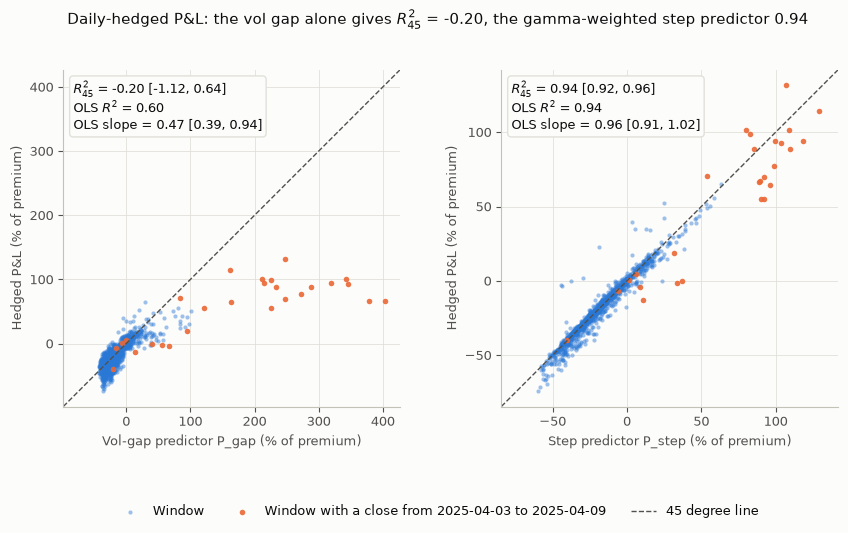

In [7]:
ladder_1 = ladders[("Full sample", 1)]
y = 100 * base.pnl
fig, axes = plt.subplots(1, 2, figsize=(10, 5.2))
for ax, name, label in zip(axes, ["P_gap", "P_step"], ["Vol-gap predictor P_gap", "Step predictor P_step"]):
    p = 100 * predictors(base)[name]
    row = ladder_1.loc[name]
    ax.scatter(p[keep], y[keep], s=9, color=BLUE, alpha=0.45, linewidths=0, label="Window")
    ax.scatter(p[april], y[april], s=16, color=ORANGE, alpha=0.9, linewidths=0,
               label="Window with a close from 2025-04-03 to 2025-04-09")
    lo, hi = min(p.min(), y.min()), max(p.max(), y.max())
    pad = 0.05 * (hi - lo)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color=INK_2, lw=1, ls="--", label="45 degree line")
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal")  # equal scales, so the 45 degree line reads as one
    ax.text(
        0.03, 0.97,
        f"$R^2_{{45}}$ = {row.r2_45:.2f} [{row.r2_lo:.2f}, {row.r2_hi:.2f}]\n"
        f"OLS $R^2$ = {row.r2_ols:.2f}\n"
        f"OLS slope = {row.beta:.2f} [{row.beta_lo:.2f}, {row.beta_hi:.2f}]",
        transform=ax.transAxes, va="top", ha="left", color=INK,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "#fcfcfb", "edgecolor": GRID},
    )
    ax.set_xlabel(f"{label} (% of premium)")
    ax.set_ylabel("Hedged P&L (% of premium)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.subplots_adjust(bottom=0.2, wspace=0.3)
fig.suptitle(
    f"Daily-hedged P&L: the vol gap alone gives $R^2_{{45}}$ = {ladder_1.loc['P_gap', 'r2_45']:.2f}, "
    f"the gamma-weighted step predictor {ladder_1.loc['P_step', 'r2_45']:.2f}"
)
save(fig, "fig6_pnl_vs_vol_gap.png")
plt.show()

## Table 4a and Figure 8: hedging error
The hedging error is e = P&L - P_gap per window, and RMSE = √(mean² + std²) with the population std. N is the number of hedge intervals, which varies with window length. Figure 8 plots each h at its mean N, with bars from the minimum to the maximum N. The synthetic reference hedges 100 GBM paths on each real window's calendar with sigma_true = sigma_i at no cost and uses each path's own realised variance in P_gap. The dashed Derman-Kamal curve is the known-vol asymptote √(π/4)·vega0·sigma_i/(√N·C0), averaged over windows. The two references measure different things, so the synthetic curve is expected to sit below the dashed one: the Derman-Kamal curve is the std of raw P&L when the vol is known (P_gap = 0), while the synthetic reference is the std of e = P&L - P_gap with each path's own realised variance, which removes the part of the hedging error that the path's realised variance explains. The asymptotic formula also overstates the std at small N.

In [8]:
rows = []
for h in H_VALUES:
    n = n_by_h[h]
    for c in C_BP:
        res = results[(h, c)]
        stats = hg.hedging_error_stats(res.pnl, res.p_gap)
        rows.append({
            "h": h, "c (bp)": c, "mean N": n.mean(), "min N": n.min(), "max N": n.max(),
            "mean P&L (%)": 100 * res.pnl.mean(), "mean e (%)": 100 * stats["mean"],
            "std e (%)": 100 * stats["std"], "RMSE e (%)": 100 * stats["rmse"],
        })
table_4a = pd.DataFrame(rows).set_index(["h", "c (bp)"])
with pd.option_context("display.max_rows", 100, "display.float_format", "{:.2f}".format):
    display(table_4a)

gbm_reference = {
    h: hg.simulate_gbm_windows(win.t, r, win.starts, win.ends, win.sigma_i, win.sigma_i, h, 0.0, N_PATHS, SEED_GBM)
    for h in H_VALUES
}
reference = pd.DataFrame(
    {h: {k: 100 * v for k, v in hg.hedging_error_stats(res.pnl, res.p_gap).items()} for h, res in gbm_reference.items()}
).T.rename_axis("h")
reference.insert(0, "mean N", [n_by_h[h].mean() for h in H_VALUES])
print("Synthetic reference (GBM on the real calendars, sigma_true = sigma_i, c = 0), % of premium:")
display(reference.round(2))
vega0 = bs_vega(S[win.starts], win.K, win.T0, r[win.starts], 0.0, win.sigma_i)
dk_scale = np.mean(vega0 * win.sigma_i / base.c0)  # Derman-Kamal curve is 100·dk_scale·√(π/4)/√N (%)
best_h = {c: table_4a.xs(c, level="c (bp)")["RMSE e (%)"].idxmin() for c in C_BP}
print(f"Derman-Kamal scale mean(vega0*sigma_i/C0) = {dk_scale:.4f}")
print("Lowest-RMSE h per cost level: " + ", ".join(f"{c} bp: h = {best_h[c]}" for c in C_BP))

mean N  min N  max N  mean P&L (%)  mean e (%)  std e (%)  \
h  c (bp)                                                              
1  0        20.58     17     22        -17.59       -5.38      25.43   
   1        20.58     17     22        -18.76       -6.55      25.40   
   5        20.58     17     22        -23.43      -11.23      25.33   
   25       20.58     17     22        -46.81      -34.61      26.30   
   100      20.58     17     22       -134.50     -122.29      43.33   
2  0        10.55      9     11        -17.12       -4.91      28.28   
   1        10.55      9     11        -18.11       -5.91      28.23   
   5        10.55      9     11        -22.08       -9.88      28.09   
   25       10.55      9     11        -41.95      -29.75      28.27   
   100      10.55      9     11       -116.46     -104.26      39.76   
3  0         7.17      6      8        -17.56       -5.36      30.86   
   1         7.17      6      8        -18.46       -6.26      30.80   
   5         7.17      6      8        -22.05       -9.85      30.61   
   25        7.17      6      8        -40.01      -27.81      30.35   
   100       7.17      6      8       -107.36      -95.16      39.01   
5  0         4.58      4      5        -18.92       -6.72      38.67   
   1         4.58      4      5        -19.70       -7.50      38.61   
   5         4.58      4      5        -22.81      -10.60      38.36   
   25        4.58      4      5        -38.33      -26.13      37.56   
   100       4.58      4      5        -96.55      -84.34      40.84   
7  0         3.20      3      4        -18.63       -6.42      39.50   
   1         3.20      3      4        -19.33       -7.13      39.44   
   5         3.20      3      4        -22.17       -9.96      39.24   
   25        3.20      3      4        -36.32      -24.11      38.54   
   100       3.20      3      4        -89.39      -77.19      40.90   
10 0         2.58      2      3        -20.16       -7.95      45.88   
   1         2.58      2      3        -20.80       -8.60      45.84   
   5         2.58      2      3        -23.38      -11.18      45.65   
   25        2.58      2      3        -36.26      -24.06      44.96   
   100       2.58      2      3        -84.57      -72.37      45.83   
21 0         1.20      1      2        -20.40       -8.19      59.89   
   1         1.20      1      2        -20.90       -8.70      59.89   
   5         1.20      1      2        -22.94      -10.74      59.87   
   25        1.20      1      2        -33.11      -20.91      59.83   
   100       1.20      1      2        -71.25      -59.05      60.54   

           RMSE e (%)  
h  c (bp)              
1  0            25.99  
   1            26.23  
   5            27.71  
   25           43.47  
   100         129.74  
2  0            28.70  
   1            28.84  
   5            29.78  
   25           41.04  
   100         111.58  
3  0            31.32  
   1            31.43  
   5            32.15  
   25           41.16  
   100         102.84  
5  0            39.25  
   1            39.33  
   5            39.80  
   25           45.75  
   100          93.71  
7  0            40.02  
   1            40.08  
   5            40.48  
   25           45.47  
   100          87.36  
10 0            46.57  
   1            46.64  
   5            47.00  
   25           50.99  
   100          85.66  
21 0            60.45  
   1            60.51  
   5            60.82  
   25           63.38  
   100          84.57

Synthetic reference (GBM on the real calendars, sigma_true = sigma_i, c = 0), % of premium:


,mean N,mean,std,rmse
h,,,,
1,20.58,0.09,11.03,11.03
2,10.55,0.13,20.40,20.40
3,7.17,0.13,26.29,26.29
5,4.58,0.21,35.51,35.51
7,3.20,-0.04,42.47,42.47
10,2.58,0.19,51.44,51.44
21,1.20,0.18,72.92,72.92


Derman-Kamal scale mean(vega0*sigma_i/C0) = 0.9997
Lowest-RMSE h per cost level: 0 bp: h = 1, 1 bp: h = 1, 5 bp: h = 1, 25 bp: h = 2, 100 bp: h = 21


Saved figures/fig8_hedging_error.png


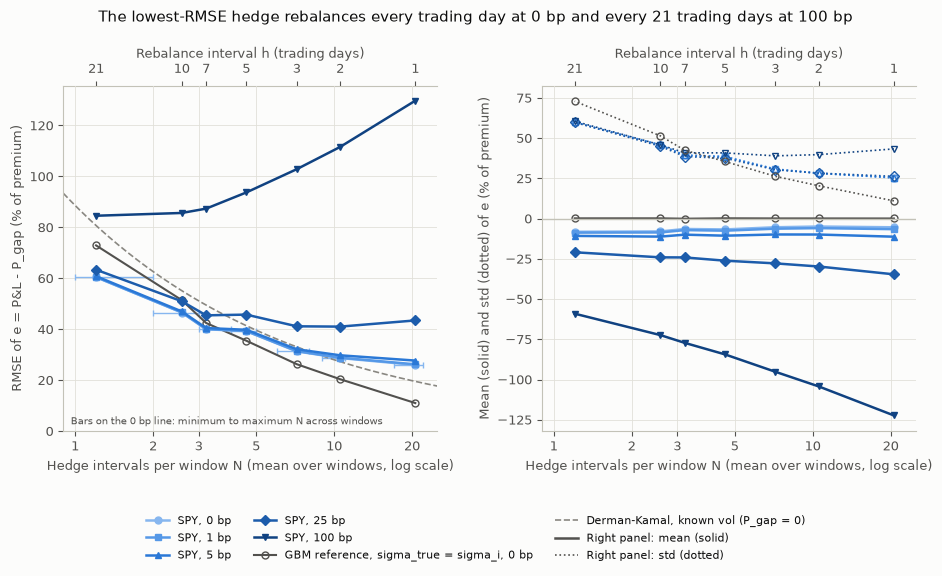

In [9]:
from matplotlib.lines import Line2D

mean_n = np.array([n_by_h[h].mean() for h in H_VALUES])
min_n = np.array([n_by_h[h].min() for h in H_VALUES])
max_n = np.array([n_by_h[h].max() for h in H_VALUES])
n_curve = np.geomspace(0.9, 25, 200)


def every(h):
    """'every trading day' or 'every h trading days'."""
    return "every trading day" if h == 1 else f"every {h} trading days"


fig, (ax_rmse, ax_ms) = plt.subplots(1, 2, figsize=(11, 5.4))
for c, colour, marker in zip(C_BP, COST_COLOURS, COST_MARKERS):
    stats = table_4a.xs(c, level="c (bp)")
    ax_rmse.errorbar(
        mean_n, stats["RMSE e (%)"], xerr=[mean_n - min_n, max_n - mean_n] if c == 0 else None,
        color=colour, marker=marker, lw=1.8, capsize=2, elinewidth=1,
    )
    ax_ms.plot(mean_n, stats["mean e (%)"], color=colour, marker=marker, lw=1.8)
    ax_ms.plot(mean_n, stats["std e (%)"], color=colour, marker=marker, lw=1.2, ls=":", mfc="none")
ax_rmse.plot(mean_n, reference["rmse"], color=INK_2, marker="o", mfc="none", lw=1.5)
ax_rmse.plot(n_curve, 100 * dk_scale * np.sqrt(np.pi / 4) / np.sqrt(n_curve), color=MUTED, ls="--", lw=1.2)
ax_rmse.text(0.02, 0.02, "Bars on the 0 bp line: minimum to maximum N across windows",
             transform=ax_rmse.transAxes, fontsize=7.5, color=INK_2)
ax_ms.plot(mean_n, reference["mean"], color=INK_2, marker="o", mfc="none", lw=1.5)
ax_ms.plot(mean_n, reference["std"], color=INK_2, marker="o", mfc="none", lw=1.2, ls=":")
ax_ms.axhline(0, color=AXIS, lw=1)
for ax in (ax_rmse, ax_ms):
    ax.set_xscale("log")
    ax.set_xlim(0.9, 25)
    ax.xaxis.set_major_locator(FixedLocator([1, 2, 3, 5, 10, 20]))
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xlabel("Hedge intervals per window N (mean over windows, log scale)")
    top = ax.secondary_xaxis("top")
    top.set_xticks(mean_n, labels=[str(h) for h in H_VALUES])
    top.xaxis.set_minor_locator(NullLocator())
    top.set_xlabel("Rebalance interval h (trading days)")
ax_rmse.set_ylabel("RMSE of e = P&L - P_gap (% of premium)")
ax_ms.set_ylabel("Mean (solid) and std (dotted) of e (% of premium)")
ax_rmse.set_ylim(bottom=0)

handles = [
    Line2D([], [], color=colour, marker=marker, lw=1.8, label=f"SPY, {c} bp")
    for c, colour, marker in zip(C_BP, COST_COLOURS, COST_MARKERS)
] + [
    Line2D([], [], color=INK_2, marker="o", mfc="none", lw=1.5, label="GBM reference, sigma_true = sigma_i, 0 bp"),
    Line2D([], [], color=MUTED, ls="--", lw=1.2, label="Derman-Kamal, known vol (P_gap = 0)"),
    Line2D([], [], color=INK_2, lw=1.8, label="Right panel: mean (solid)"),
    Line2D([], [], color=INK_2, lw=1.2, ls=":", label="Right panel: std (dotted)"),
]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=8)
fig.subplots_adjust(bottom=0.24, wspace=0.28)
fig.suptitle(
    f"The lowest-RMSE hedge rebalances {every(best_h[0])} at 0 bp and {every(best_h[100])} at 100 bp",
    y=1.02,
)
save(fig, "fig8_hedging_error.png")
plt.show()

## Weekday diagnostic of P_step residuals
Under daily hedging without costs, each interval's hedged P&L minus its P_step term is grouped by the weekday of the interval's closing day. Monday intervals span the weekend: P_step charges three calendar days of sigma_i² there, against roughly one trading day of realised variance. Means are per interval in percent of premium, with 95% moving block bootstrap intervals from the full-sample resamples. η² is the share of residual variance that the weekday means explain.

In [10]:
weekday_table, eta2 = hg.weekday_diagnostic(
    base.interval_pnl, base.interval_p_step, dates, win.starts, win.ends, 1, boot_full
)
shown = weekday_table.copy()
for col in ["pnl", "p_step", "residual", "residual_lo", "residual_hi"]:
    shown[col] = 100 * shown[col]
shown = shown.rename(columns={
    "calendar_days": "mean calendar days", "pnl": "mean P&L (%)", "p_step": "mean P_step (%)",
    "residual": "mean residual (%)", "residual_lo": "residual lo (%)", "residual_hi": "residual hi (%)",
    "share": "share of total residual",
})
with pd.option_context("display.float_format", "{:.4f}".format):
    display(shown)
window_resid = base.pnl - base.p_step
print(f"eta^2, share of residual variance explained by weekday means: {eta2:.4f}")
print(f"Window residual P&L - P_step (h = 1, c = 0): mean {100 * window_resid.mean():+.3f}%, "
      f"std {100 * window_resid.std():.3f}% of premium")

,intervals,mean calendar days,mean P&L (%),mean P_step (%),mean residual (%),residual lo (%),residual hi (%),share of total residual
Monday,4410,3.0381,-4.3637,-4.2041,-0.1596,-0.2244,-0.0978,0.9534
Tuesday,5138,1.3025,-0.8988,-0.9054,0.0065,-0.0380,0.0435,-0.0453
Wednesday,5350,1.0037,-0.0226,-0.1017,0.0791,-0.0150,0.2054,-0.5731
Thursday,5222,1.0115,0.2656,0.3524,-0.0868,-0.2230,0.0031,0.6140
Friday,5233,1.0390,0.1775,0.1847,-0.0072,-0.1147,0.0857,0.0510
All,25353,1.4270,-0.8546,-0.8255,-0.0291,-0.0623,0.0019,1.0000


eta^2, share of residual variance explained by weekday means: 0.0038
Window residual P&L - P_step (h = 1, c = 0): mean -0.599%, std 5.725% of premium


## Weekend variance ratio
The engine, like VIX, counts time in calendar days, so the weekday diagnostic charges a Friday-to-Monday interval three days of sigma_i². The ratio of the mean squared Friday-to-Monday log return to the mean squared single-weekday log return says which clock SPY's realised variance follows: 3 under calendar time, 1 under trading-day time. Returns across holidays enter neither mean. The interval is a moving block bootstrap over the daily returns in date order (blocks of 21 returns, 2,000 resamples, seed 20260930). Next to it is the realised shortfall 1 - mean RV / mean sigma_i²·T0 of the windows. The ratio is a property of the returns and does not depend on sigma_i, while the window total follows the shortfall: the clock changes when P&L is booked within a window (Monday losses against weekday gains), not how much.

In [11]:
WEEKEND_BLOCK = 21  # daily returns per block in the bootstrap of the weekend ratio


def weekend_ratio(first, last):
    """Weekend variance ratio over the returns between history closes first and last, with its interval."""
    boot = hg.block_bootstrap_indices(last - first, WEEKEND_BLOCK, N_RESAMPLES, SEED_BOOT)
    return hg.weekend_variance_ratio(dates[first : last + 1], S[first : last + 1], boot)


def shortfall(sigma, T0, rv):
    """Realised shortfall over windows: 1 - mean RV / mean implied total variance sigma²·T0."""
    return 1.0 - np.mean(rv) / np.mean(sigma**2 * T0)


weekend_all = weekend_ratio(win.starts[0], win.ends[-1])
print(f"Returns from {dates[win.starts[0]].date()} to {dates[win.ends[-1]].date()}: {weekend_all['n_weekend']} "
      f"Friday-to-Monday and {weekend_all['n_weekday']} single-weekday returns (holiday gaps excluded)")
print(f"Weekend variance ratio, mean squared Friday-to-Monday over single-weekday log return: "
      f"{weekend_all['ratio']:.2f} [{weekend_all['lo']:.2f}, {weekend_all['hi']:.2f}] "
      f"(95% moving block bootstrap, blocks of {WEEKEND_BLOCK} returns)")
print(f"Calendar-time pricing charges a weekend 3 weekday units of variance, trading-day time 1; "
      f"3 inside the interval: {bool(weekend_all['lo'] <= 3 <= weekend_all['hi'])}")
print(f"Realised shortfall 1 - mean RV / mean sigma_i^2*T0 over the {win.starts.size} VIX windows: "
      f"{shortfall(win.sigma_i, win.T0, rv):.1%}")

Returns from 2021-10-01 to 2026-09-25: 224 Friday-to-Monday and 976 single-weekday returns (holiday gaps excluded)
Weekend variance ratio, mean squared Friday-to-Monday over single-weekday log return: 0.70 [0.47, 0.96] (95% moving block bootstrap, blocks of 21 returns)
Calendar-time pricing charges a weekend 3 weekday units of variance, trading-day time 1; 3 inside the interval: False
Realised shortfall 1 - mean RV / mean sigma_i^2*T0 over the 1232 VIX windows: 22.9%


## Textbook reference
The section 3 synthetic set (3,000 windows, 21 daily steps, sigma_true drawn around sigma_i) is computed here only as the textbook reference for the ladder: medians over 40 seed pairs of R²_45 and the OLS R² of each predictor. The headline compares real data with the real-calendar GBM benchmark in Table 4b.

In [12]:
TEXTBOOK_STATS = {"r2_45": hg.r2_45, "r2_ols": hg.r2_ols}
textbook = {h: {stat: [] for stat in TEXTBOOK_STATS} for h in (1, 5)}
for seed_vols, seed_paths in SEEDS_TEXTBOOK:
    paths, times, sig = hg.synthetic_window_set(3000, seed_vols, seed_paths)
    for h, stats in textbook.items():
        res = hg.simulate_window(paths, times, 0.0, sig, 100.0, h, 0.0)
        for stat, values in stats.items():
            values.append([TEXTBOOK_STATS[stat](res.pnl, p) for p in predictors(res).values()])
textbook_median = {
    h: pd.DataFrame({stat: np.median(v, axis=0) for stat, v in stats.items()}, index=PREDICTORS)
    for h, stats in textbook.items()
}


def slash(values):
    """Values to two decimals, separated by slashes."""
    return " / ".join(f"{x:.2f}" for x in values)


for h, m in textbook_median.items():
    print(
        f"Textbook reference only (section 3 set, median of {len(SEEDS_TEXTBOOK)} seed pairs), h = {h}, "
        f"{' / '.join(PREDICTORS)}: R2_45 = {slash(m['r2_45'])}; OLS R2 = {slash(m['r2_ols'])}"
    )

Textbook reference only (section 3 set, median of 40 seed pairs), h = 1, P_gap / P_price / P_path / P_step: R2_45 = 0.76 / 0.83 / 0.93 / 0.98; OLS R2 = 0.78 / 0.83 / 0.93 / 0.98
Textbook reference only (section 3 set, median of 40 seed pairs), h = 5, P_gap / P_price / P_path / P_step: R2_45 = 0.40 / 0.44 / 0.44 / 0.89; OLS R2 = 0.41 / 0.44 / 0.44 / 0.89


## Hedging headline numbers
Every number the hedging half of the headline needs, printed in one place.

In [13]:
def ladder_line(row):
    """R2_45, OLS R2, slope and intercept of one ladder row, with bootstrap intervals when present."""
    if np.isnan(row.r2_lo):
        return (f"R2_45 = {row.r2_45:.2f}, OLS R2 = {row.r2_ols:.2f}, slope = {row.beta:.2f}, "
                f"intercept = {100 * row.alpha:+.1f}%")
    return (f"R2_45 = {row.r2_45:.2f} [{row.r2_lo:.2f}, {row.r2_hi:.2f}], OLS R2 = {row.r2_ols:.2f}, "
            f"slope = {row.beta:.2f} [{row.beta_lo:.2f}, {row.beta_hi:.2f}], intercept = {100 * row.alpha:+.1f}%")


bench_1, ex_april_1 = ladders[("GBM benchmark", 1)], ladders[("Excluding April 2025", 1)]
bench_ex_april_1 = ladders[("GBM benchmark excluding April 2025", 1)]
print("=" * 100)
print("HEDGING HEADLINE NUMBERS")
print("P&L as % of the premium carried to expiry; daily hedging (h = 1) and no costs unless stated.")
print("=" * 100)
print(f"Sample: {win.starts.size} windows of 30 calendar days, starts {start_dates[0].date()} to "
      f"{start_dates[-1].date()}, {steps.min()} to {steps.max()} steps, mean N = {n_by_h[1].mean():.1f}")
print(f"Implied above realised (sigma_i^2*T0 > RV): {share_implied_above:.1%} of windows")
print(f"Mean VIX {win.sigma_i.mean():.1%}, mean realised vol {sigma_r.mean():.1%}")
print(f"Hedged P&L of the long call: mean {100 * base.pnl.mean():+.1f}%, std {100 * base.pnl.std():.1f}%")
print(f"Weekend variance ratio {weekend_all['ratio']:.2f} [{weekend_all['lo']:.2f}, {weekend_all['hi']:.2f}] "
      f"against 3 under calendar time; realised shortfall 1 - mean RV / mean sigma_i^2*T0 = "
      f"{shortfall(win.sigma_i, win.T0, rv):.1%}")
print()
print("R2 ladder, real SPY windows [95% moving block bootstrap]:")
for name in PREDICTORS:
    print(f"  {name:<7} {ladder_line(ladder_1.loc[name])}")
print("GBM benchmark on the same calendars (sigma_true = realised vol, sigma_i = VIX, 100 paths per window):")
for name in PREDICTORS:
    print(f"  {name:<7} {ladder_line(bench_1.loc[name])}")
for h, m in textbook_median.items():
    print(f"Textbook reference only (section 3 synthetic set), h = {h}, {' / '.join(PREDICTORS)}: "
          f"R2_45 = {slash(m['r2_45'])}; OLS R2 = {slash(m['r2_ols'])}")
print()
print(f"Excluding April 2025 ({keep.sum()} windows):")
for name in PREDICTORS:
    print(f"  {name:<7} {ladder_line(ex_april_1.loc[name])}")
print(f"GBM benchmark excluding April 2025 (the paths of the same {keep.sum()} windows):")
for name in PREDICTORS:
    print(f"  {name:<7} {ladder_line(bench_ex_april_1.loc[name])}")
print()
print(f"Headline intervals at block lengths {' / '.join(str(b) for b in blocks)} windows [95% moving block bootstrap]:")
for sample in samples_1:
    print(f"  {sample}:")
    for name in PREDICTORS:
        rows = [table_4b_blocks.loc[(sample, block, name)] for block in blocks]
        print(f"    {name:<7} R2_45 = {rows[0].r2_45:.2f} "
              + " / ".join(f"[{row.r2_lo:.2f}, {row.r2_hi:.2f}]" for row in rows)
              + f"; slope = {rows[0].beta:.2f} "
              + " / ".join(f"[{row.beta_lo:.2f}, {row.beta_hi:.2f}]" for row in rows))
print(f"Non-overlapping subsamples ({len(subsamples)} offsets at stride {STRIDE}, "
      f"{min(sizes)} to {max(sizes)} windows each; sensitivity to window alignment, not a sampling distribution):")
for name in PREDICTORS:
    row = table_4c.loc[(1, name)]
    print(f"  {name:<7} offset 0: R2_45 = {row['r2_45_offset0']:.2f}, OLS R2 = {row['r2_ols_offset0']:.2f}, "
          f"slope = {row['beta_offset0']:.2f}; across all: R2_45 median {row['r2_45_median']:.2f} "
          f"({row['r2_45_min']:.2f} to {row['r2_45_max']:.2f}), OLS R2 median {row['r2_ols_median']:.2f} "
          f"({row['r2_ols_min']:.2f} to {row['r2_ols_max']:.2f}), "
          f"slope median {row['beta_median']:.2f} ({row['beta_min']:.2f} to {row['beta_max']:.2f})")
print()
rmse_1 = table_4a.xs(1, level="h")
print("Hedging error e = P&L - P_gap, daily: RMSE " + ", ".join(
    f"{rmse_1.loc[c, 'RMSE e (%)']:.1f}% at {c} bp" for c in C_BP))
print(f"GBM reference RMSE, daily, 0 bp: {reference.loc[1, 'rmse']:.1f}%")
print("Lowest-RMSE rebalance interval: " + ", ".join(f"h = {best_h[c]} at {c} bp" for c in C_BP))

HEDGING HEADLINE NUMBERS
P&L as % of the premium carried to expiry; daily hedging (h = 1) and no costs unless stated.
Sample: 1232 windows of 30 calendar days, starts 2021-10-01 to 2026-08-28, 17 to 22 steps, mean N = 20.6
Implied above realised (sigma_i^2*T0 > RV): 84.3% of windows
Mean VIX 19.2%, mean realised vol 15.8%
Hedged P&L of the long call: mean -17.6%, std 23.7%
Weekend variance ratio 0.70 [0.47, 0.96] against 3 under calendar time; realised shortfall 1 - mean RV / mean sigma_i^2*T0 = 22.9%

R2 ladder, real SPY windows [95% moving block bootstrap]:
  P_gap   R2_45 = -0.20 [-1.12, 0.64], OLS R2 = 0.60, slope = 0.47 [0.39, 0.94], intercept = -11.8%
  P_price R2_45 = 0.58 [0.50, 0.69], OLS R2 = 0.73, slope = 0.69 [0.63, 0.85], intercept = -5.0%
  P_path  R2_45 = 0.67 [0.47, 0.85], OLS R2 = 0.80, slope = 0.72 [0.61, 1.02], intercept = -5.6%
  P_step  R2_45 = 0.94 [0.92, 0.96], OLS R2 = 0.94, slope = 0.96 [0.91, 1.02], intercept = -1.3%
GBM benchmark on the same calendars (sigma_

The sensitivity run sets sigma_i to VIX minus the variance-swap gap. That gap comes from the Stage 4 surface, so the run and its Table 4 row are added in Stage 4.

## Stage 5c: OptionMetrics sensitivity
VIX is a variance-swap level, so it sits above at-the-money implied vol. This section reruns the daily, cost-free study with sigma_i set to the OptionMetrics 30-day ATM-forward implied vol (the mean of the standardised call and put), next to a VIX run on exactly the same windows, following DESIGN.md section 3. It then measures the daily gap between VIX and ATM vol and how much of it the 30-day risk reversal and butterfly explain. The first cell also compares the ATM vol with the surface's 50-delta call IV, in aggregate.

The OptionMetrics files are licensed through WRDS. They stay in data/raw/ (gitignored) and are never committed. This section prints only aggregates (means, medians, standard deviations, percentiles, shares and counts) and a chart of monthly means, never a single day's value such as a minimum or a maximum. Without the files it prints one line and skips, so the notebook still runs top to bottom on a clean install.

In [14]:
from volsurf.data import load_optionmetrics

OM_LAST = "2025-08-29"  # last OptionMetrics date: Stage 5c windows start on or before it
GAP_BLOCK = 21  # trading days per block in the bootstrap of the daily gap regression


def vol_points(x):
    """Mean, median, std (ddof 0) and 5th and 95th percentiles of a daily series, in vol points.

    Licensing: these aggregates are all this section prints of a daily OptionMetrics series, never
    a minimum, a maximum or any other value of a single day.
    """
    x = 100 * np.asarray(x, dtype=float)
    p5, p95 = np.percentile(x, [5, 95])
    return (f"mean {x.mean():+.2f}, median {np.median(x):+.2f}, std {x.std():.2f}, "
            f"5th to 95th percentile {p5:+.2f} to {p95:+.2f}")


om = load_optionmetrics()  # licensed WRDS files in data/raw/; None when either is absent
if om is None:
    print("Stage 5c skipped: the licensed OptionMetrics files are not in data/raw/")
else:
    om_rows = np.flatnonzero(start_dates <= pd.Timestamp(OM_LAST))
    sigma_atm = om["sigma_atm"].reindex(start_dates[om_rows]).to_numpy()
    assert not np.isnan(sigma_atm).any(), "every Stage 5c window start needs an OptionMetrics ATM vol"
    atm_minus_50d = om["sigma_atm"] - om["call_50d"]
    print(f"OptionMetrics: {om.index.size} dates, {om.index[0].date()} to {om.index[-1].date()}")
    print(
        f"Stage 5c windows: {om_rows.size} of {win.starts.size}, starts {start_dates[om_rows][0].date()} "
        f"to {start_dates[om_rows][-1].date()}, each with an ATM vol at t0"
    )
    print(f"Cross-check, ATM vol minus the 50-delta call IV of the surface, vol points: {vol_points(atm_minus_50d)}")
    for points in (1, 2):
        above = atm_minus_50d.abs() > points / 100
        by_year = above.groupby(above.index.year).sum()
        print(
            f"Dates with |ATM vol minus 50-delta call IV| above {points} vol point{'s' if points > 1 else ''}: "
            f"{above.sum()} of {above.size} ({above.mean():.1%}); by year: "
            + ", ".join(f"{year} {n}" for year, n in by_year.items())
        )

OptionMetrics: 1068 dates, 2021-06-01 to 2025-08-29
Stage 5c windows: 982 of 1232, starts 2021-10-01 to 2025-08-29, each with an ATM vol at t0
Cross-check, ATM vol minus the 50-delta call IV of the surface, vol points: mean +0.06, median +0.03, std 0.43, 5th to 95th percentile -0.59 to +0.70
Dates with |ATM vol minus 50-delta call IV| above 1 vol point: 33 of 1068 (3.1%); by year: 2021 18, 2022 8, 2023 2, 2024 2, 2025 3
Dates with |ATM vol minus 50-delta call IV| above 2 vol points: 1 of 1068 (0.1%); by year: 2021 0, 2022 0, 2023 0, 2024 0, 2025 1


## Table 4d: sigma_i = OptionMetrics ATM vol against sigma_i = VIX
Both runs hedge daily (h = 1) without costs, on the same windows and with the same strikes K = F0, so only sigma_i differs: it sets the premium, the deltas and the predictors. The ladder has the four rungs and the OLS R² of Table 4b. Intervals are 95% moving block bootstrap percentiles (blocks of 42 windows) redrawn on this shorter sequence, and the two runs share the same resamples. The April 2025 rows drop every window with a close from 2025-04-03 to 2025-04-09 and resample the rest. The stride-22 rows take windows k, k + 22, k + 44, ... of these windows for each offset k, as in Table 4c; their range is a sensitivity to window alignment, not a sampling distribution.

In [15]:
if om is not None:
    starts_5c, ends_5c, T0_5c, K_5c = win.starts[om_rows], win.ends[om_rows], win.T0[om_rows], win.K[om_rows]
    sigma_5c = {"VIX": win.sigma_i[om_rows], "OptionMetrics ATM": sigma_atm}
    runs_5c = {
        label: hg.simulate_windows(S, win.t, r, starts_5c, ends_5c, sig, K_5c, 1, 0.0)
        for label, sig in sigma_5c.items()
    }
    diff_5b = max(
        np.max(np.abs(getattr(runs_5c["VIX"], name) - getattr(base, name)[om_rows]))
        for name in ("pnl", "p_gap", "p_path", "p_step")
    )
    print(f"VIX run against the Stage 5b results on these windows: largest difference {diff_5b:.1e}")

    sigma_r_5c = np.sqrt(runs_5c["VIX"].rv / T0_5c)
    keep_5c = ~april[om_rows]
    boot_5c = hg.block_bootstrap_indices(om_rows.size, BLOCK, N_RESAMPLES, SEED_BOOT)
    boot_5c_keep = hg.block_bootstrap_indices(int(keep_5c.sum()), BLOCK, N_RESAMPLES, SEED_BOOT)
    subsamples_5c = hg.stride_subsamples(starts_5c, ends_5c, STRIDE)  # raises if any two windows share a return
    sizes_5c = [sub.size for sub in subsamples_5c]
    print(f"April 2025 exclusion: {(~keep_5c).sum()} windows removed, {keep_5c.sum()} kept")
    print(f"{len(subsamples_5c)} subsamples at stride {STRIDE}, {min(sizes_5c)} to {max(sizes_5c)} windows each")
    print(f"Mean realised vol sigma_r over these windows: {sigma_r_5c.mean():.2%}")

    summary_5c, ladders_5c, stride_5c = {}, {}, {}
    for label, res in runs_5c.items():
        sig = sigma_5c[label]
        summary_5c[label] = {
            "windows": sig.size,
            "mean sigma_i (%)": 100 * sig.mean(),
            "share sigma_i^2*T0 > RV (%)": 100 * np.mean(sig**2 * T0_5c > res.rv),
            "mean P&L (%)": 100 * res.pnl.mean(),
            "std P&L (%)": 100 * res.pnl.std(),
        }
        ladders_5c[(label, "Full sample")] = hg.r2_ladder(res.pnl, predictors(res), boot_5c)
        ladders_5c[(label, "Excluding April 2025")] = hg.r2_ladder(
            res.pnl[keep_5c], predictors(res, keep_5c), boot_5c_keep
        )
        stride_5c[label] = hg.stride_ladder(res.pnl, predictors(res), subsamples_5c)
    table_4d_summary = pd.DataFrame.from_dict(summary_5c, orient="index").rename_axis("sigma_i")
    table_4d_ladder = pd.concat(ladders_5c, names=["sigma_i", "sample", "predictor"])
    table_4d_stride = pd.concat(stride_5c, names=["sigma_i", "predictor"])
    with pd.option_context("display.max_rows", 100, "display.float_format", "{:.3f}".format):
        display(table_4d_summary)
        display(table_4d_ladder)
        display(table_4d_stride)

    for sample in ("Full sample", "Excluding April 2025"):
        print(f"{sample}, h = 1, c = 0 [95% moving block bootstrap]:")
        for name in PREDICTORS:
            for label in sigma_5c:
                print(f"  {name:<7} {label:<17} {ladder_line(table_4d_ladder.loc[(label, sample, name)])}")
    print(f"Stride-22 subsamples, median (min to max) across {len(subsamples_5c)} offsets "
          "(sensitivity to window alignment, not a sampling distribution):")
    for name in PREDICTORS:
        for label in sigma_5c:
            row = table_4d_stride.loc[(label, name)]
            print(f"  {name:<7} {label:<17} R2_45 {row['r2_45_median']:.2f} ({row['r2_45_min']:.2f} to "
                  f"{row['r2_45_max']:.2f}), OLS R2 {row['r2_ols_median']:.2f} ({row['r2_ols_min']:.2f} to "
                  f"{row['r2_ols_max']:.2f}), slope {row['beta_median']:.2f} ({row['beta_min']:.2f} to "
                  f"{row['beta_max']:.2f})")

VIX run against the Stage 5b results on these windows: largest difference 0.0e+00
April 2025 exclusion: 27 windows removed, 955 kept
22 subsamples at stride 22, 44 to 45 windows each
Mean realised vol sigma_r over these windows: 16.56%


,windows,mean sigma_i (%),share sigma_i^2*T0 > RV (%),mean P&L (%),std P&L (%)
sigma_i,,,,,
VIX,982,19.438,80.957,-14.192,24.011
OptionMetrics ATM,982,16.581,62.831,0.804,27.115


n  r2_45  r2_lo  r2_hi  \
sigma_i           sample               predictor                             
VIX               Full sample          P_gap      982 -0.379 -1.445  0.660   
                                       P_price    982  0.569  0.481  0.678   
                                       P_path     982  0.620  0.396  0.830   
                                       P_step     982  0.943  0.920  0.960   
                  Excluding April 2025 P_gap      955  0.604  0.491  0.692   
                                       P_price    955  0.605  0.493  0.696   
                                       P_path     955  0.812  0.759  0.846   
                                       P_step     955  0.947  0.923  0.963   
OptionMetrics ATM Full sample          P_gap      982 -1.314 -3.429  0.551   
                                       P_price    982  0.455  0.253  0.643   
                                       P_path     982  0.455  0.026  0.781   
                                       P_step     982  0.912  0.878  0.942   
                  Excluding April 2025 P_gap      955  0.336 -0.045  0.623   
                                       P_price    955  0.553  0.376  0.657   
                                       P_path     955  0.750  0.657  0.805   
                                       P_step     955  0.920  0.881  0.952   

                                                  r2_ols  alpha  beta  \
sigma_i           sample               predictor                        
VIX               Full sample          P_gap       0.637 -0.101 0.447   
                                       P_price     0.762 -0.039 0.667   
                                       P_path      0.799 -0.050 0.679   
                                       P_step      0.947 -0.012 0.947   
                  Excluding April 2025 P_gap       0.671 -0.050 0.770   
                                       P_price     0.702 -0.022 0.746   
                                       P_path      0.824 -0.004 0.912   
                                       P_step      0.947 -0.003 0.990   
OptionMetrics ATM Full sample          P_gap       0.581 -0.016 0.359   
                                       P_price     0.714  0.009 0.625   
                                       P_path      0.735 -0.002 0.619   
                                       P_step      0.922 -0.004 0.909   
                  Excluding April 2025 P_gap       0.622 -0.012 0.597   
                                       P_price     0.674  0.015 0.713   
                                       P_path      0.776  0.011 0.858   
                                       P_step      0.922 -0.000 0.958   

                                                  beta_lo  beta_hi  
sigma_i           sample               predictor                    
VIX               Full sample          P_gap        0.374    0.879  
                                       P_price      0.616    0.809  
                                       P_path       0.586    0.979  
                                       P_step       0.903    1.013  
                  Excluding April 2025 P_gap        0.680    0.945  
                                       P_price      0.694    0.833  
                                       P_path       0.834    1.008  
                                       P_step       0.964    1.022  
OptionMetrics ATM Full sample          P_gap        0.293    0.718  
                                       P_price      0.555    0.811  
                                       P_path       0.510    0.934  
                                       P_step       0.851    0.983  
                  Excluding April 2025 P_gap        0.497    0.781  
                                       P_price      0.612    0.837  
                                       P_path       0.765    0.972  
                                       P_step       0.917    0.998

n_offset0  r2_45_offset0  r2_45_median  \
sigma_i           predictor                                           
VIX               P_gap             45          0.272         0.205   
                  P_price           45          0.415         0.585   
                  P_path            45          0.409         0.588   
                  P_step            45          0.948         0.954   
OptionMetrics ATM P_gap             45          0.011        -0.694   
                  P_price           45          0.354         0.493   
                  P_path            45          0.306         0.480   
                  P_step            45          0.952         0.928   

                             r2_45_min  r2_45_max  r2_ols_offset0  \
sigma_i           predictor                                         
VIX               P_gap         -4.820      0.737           0.509   
                  P_price       -0.168      0.818           0.585   
                  P_path         0.099      0.884           0.609   
                  P_step         0.793      0.980           0.957   
OptionMetrics ATM P_gap         -9.501      0.531           0.448   
                  P_price       -0.670      0.793           0.523   
                  P_path        -0.227      0.816           0.532   
                  P_step         0.760      0.962           0.954   

                             r2_ols_median  r2_ols_min  r2_ols_max  \
sigma_i           predictor                                          
VIX               P_gap              0.706       0.509       0.861   
                  P_price            0.796       0.585       0.895   
                  P_path             0.844       0.609       0.921   
                  P_step             0.960       0.824       0.984   
OptionMetrics ATM P_gap              0.657       0.448       0.833   
                  P_price            0.741       0.523       0.853   
                  P_path             0.777       0.532       0.882   
                  P_step             0.933       0.800       0.977   

                             beta_offset0  beta_median  beta_min  beta_max  
sigma_i           predictor                                                 
VIX               P_gap             0.608        0.548     0.256     0.805  
                  P_price           0.651        0.697     0.477     0.898  
                  P_path            0.636        0.682     0.526     0.834  
                  P_step            0.943        0.941     0.838     1.062  
OptionMetrics ATM P_gap             0.504        0.425     0.189     0.671  
                  P_price           0.643        0.665     0.421     0.842  
                  P_path            0.606        0.622     0.460     0.794  
                  P_step            0.964        0.893     0.796     1.171

Full sample, h = 1, c = 0 [95% moving block bootstrap]:
  P_gap   VIX               R2_45 = -0.38 [-1.44, 0.66], OLS R2 = 0.64, slope = 0.45 [0.37, 0.88], intercept = -10.1%
  P_gap   OptionMetrics ATM R2_45 = -1.31 [-3.43, 0.55], OLS R2 = 0.58, slope = 0.36 [0.29, 0.72], intercept = -1.6%
  P_price VIX               R2_45 = 0.57 [0.48, 0.68], OLS R2 = 0.76, slope = 0.67 [0.62, 0.81], intercept = -3.9%
  P_price OptionMetrics ATM R2_45 = 0.46 [0.25, 0.64], OLS R2 = 0.71, slope = 0.62 [0.56, 0.81], intercept = +0.9%
  P_path  VIX               R2_45 = 0.62 [0.40, 0.83], OLS R2 = 0.80, slope = 0.68 [0.59, 0.98], intercept = -5.0%
  P_path  OptionMetrics ATM R2_45 = 0.45 [0.03, 0.78], OLS R2 = 0.74, slope = 0.62 [0.51, 0.93], intercept = -0.2%
  P_step  VIX               R2_45 = 0.94 [0.92, 0.96], OLS R2 = 0.95, slope = 0.95 [0.90, 1.01], intercept = -1.2%
  P_step  OptionMetrics ATM R2_45 = 0.91 [0.88, 0.94], OLS R2 = 0.92, slope = 0.91 [0.85, 0.98], intercept = -0.4%
Excluding April 202

## Precision of the mean P&L
Mean hedged P&L under each sigma_i, and the paired difference VIX minus ATM window by window, with 95% moving block bootstrap intervals. Blocks of 42 windows use the Table 4d resamples; blocks of 84 and 126 windows, as in the headline sensitivity, use their own 2,000 resamples with the same seed. Each run's P&L is a fraction of its own premium, which is larger at VIX, so the difference is in points of premium rather than money. The stride columns give the median and range of the mean across the 22 stride-22 subsamples, a sensitivity to window alignment rather than a sampling distribution.

In [16]:
if om is not None:
    pnl_5c = {label: res.pnl for label, res in runs_5c.items()}
    pnl_5c["VIX minus ATM"] = pnl_5c["VIX"] - pnl_5c["OptionMetrics ATM"]  # paired, window by window
    boot_5c_blocks = {
        block: hg.block_bootstrap_indices(om_rows.size, block, N_RESAMPLES, SEED_BOOT)
        for block in (BLOCK, *BLOCKS_SENSITIVITY)
    }
    assert np.array_equal(boot_5c_blocks[BLOCK], boot_5c)  # block 42 reproduces the Table 4d resamples
    precision_rows = {}
    for label, y in pnl_5c.items():
        row = {"mean (%)": 100 * y.mean()}
        for block, boot in boot_5c_blocks.items():
            row[f"lo {block} (%)"], row[f"hi {block} (%)"] = 100 * np.percentile(y[boot].mean(axis=1), [2.5, 97.5])
        stride_mean = np.array([y[sub].mean() for sub in subsamples_5c])
        row.update({
            "stride median (%)": 100 * np.median(stride_mean),
            "stride min (%)": 100 * stride_mean.min(),
            "stride max (%)": 100 * stride_mean.max(),
        })
        precision_rows[label] = row
    table_4d_precision = pd.DataFrame.from_dict(precision_rows, orient="index").rename_axis("hedged P&L")
    with pd.option_context("display.float_format", "{:.2f}".format):
        display(table_4d_precision)

,mean (%),lo 42 (%),hi 42 (%),lo 84 (%),hi 84 (%),lo 126 (%),hi 126 (%),stride median (%),stride min (%),stride max (%)
hedged P&L,,,,,,,,,,
VIX,-14.19,-18.81,-7.14,-18.57,-6.96,-18.10,-7.29,-14.45,-16.21,-11.59
OptionMetrics ATM,0.80,-4.32,8.26,-4.19,8.41,-4.45,8.57,0.45,-1.85,3.75
VIX minus ATM,-15.00,-17.60,-12.67,-17.88,-11.90,-18.11,-11.56,-15.06,-16.85,-13.90


## Weekend ratio against the realised shortfall
The weekend variance ratio over the returns of the Stage 5c windows, next to the realised shortfall 1 - mean RV / mean sigma_i²·T0 for sigma_i = VIX and sigma_i = OptionMetrics ATM vol on the same windows. The ratio uses only SPY returns, so it is the same for both runs, while the shortfall is not: the weekend effect changes when P&L is booked within a window, not its total.

In [17]:
if om is not None:
    weekend_5c = weekend_ratio(starts_5c[0], ends_5c[-1])
    print(f"Weekend variance ratio over the returns of the {starts_5c.size} Stage 5c windows "
          f"({dates[starts_5c[0]].date()} to {dates[ends_5c[-1]].date()}): {weekend_5c['ratio']:.2f} "
          f"[{weekend_5c['lo']:.2f}, {weekend_5c['hi']:.2f}], the same for both sigma_i")
    for label, sig in sigma_5c.items():
        print(f"Realised shortfall 1 - mean RV / mean sigma_i^2*T0, sigma_i = {label}: "
              f"{shortfall(sig, T0_5c, runs_5c[label].rv):.1%}")

Weekend variance ratio over the returns of the 982 Stage 5c windows (2021-10-01 to 2025-09-26): 0.67 [0.44, 0.94], the same for both sigma_i
Realised shortfall 1 - mean RV / mean sigma_i^2*T0, sigma_i = VIX: 17.2%
Realised shortfall 1 - mean RV / mean sigma_i^2*T0, sigma_i = OptionMetrics ATM: -12.0%


## Scaling diagnostic
As a fraction of the premium, P_gap is about (sigma_r² - sigma_i²)/(2·sigma_i²), because the ATM premium is close to vega0·sigma_i, so the same variance gap weighs more when sigma_i is lower. To separate that scaling from the fit itself, the ladder is recomputed with P&L and predictors as fractions of S0·G0 (the spot carried to expiry) instead of C0·G0, that is multiplied by C0/S0 in each window, and shown in basis points of S0 (alpha too). The resamples are those of Table 4d. The Spearman rank correlation of P&L with each predictor is given under both normalisations.

In [18]:
if om is not None:
    from scipy.stats import spearmanr

    ladders_s0, spearman_rows = {}, []
    for label, res in runs_5c.items():
        to_bp_s0 = 1e4 * res.c0 / S[starts_5c]  # fraction of C0·G0 to bp of S0·G0, per window
        y_s0 = res.pnl * to_bp_s0
        p_s0 = {name: p * to_bp_s0 for name, p in predictors(res).items()}
        ladders_s0[(label, "Full sample")] = hg.r2_ladder(y_s0, p_s0, boot_5c)
        ladders_s0[(label, "Excluding April 2025")] = hg.r2_ladder(
            y_s0[keep_5c], {name: p[keep_5c] for name, p in p_s0.items()}, boot_5c_keep
        )
        for norm, y, p in (("C0", res.pnl, predictors(res)), ("S0", y_s0, p_s0)):
            row = {"sigma_i": label, "normalisation": norm}
            row.update({name: spearmanr(y, p[name]).statistic for name in PREDICTORS})
            spearman_rows.append(row)
    table_4d_s0 = pd.concat(ladders_s0, names=["sigma_i", "sample", "predictor"])
    table_4d_spearman = pd.DataFrame(spearman_rows).set_index(["sigma_i", "normalisation"])
    print("Ladder with P&L and predictors in bp of S0:")
    with pd.option_context("display.max_rows", 100, "display.float_format", "{:.3f}".format):
        display(table_4d_s0)
        print("Spearman rank correlation of P&L with each predictor, h = 1, c = 0:")
        display(table_4d_spearman)

Ladder with P&L and predictors in bp of S0:


n  r2_45  r2_lo  r2_hi  \
sigma_i           sample               predictor                             
VIX               Full sample          P_gap      982 -0.263 -1.119  0.682   
                                       P_price    982  0.586  0.505  0.685   
                                       P_path     982  0.584  0.330  0.836   
                                       P_step     982  0.941  0.914  0.962   
                  Excluding April 2025 P_gap      955  0.641  0.563  0.706   
                                       P_price    955  0.602  0.487  0.704   
                                       P_path     955  0.825  0.781  0.854   
                                       P_step     955  0.950  0.927  0.966   
OptionMetrics ATM Full sample          P_gap      982 -1.262 -2.879  0.544   
                                       P_price    982  0.481  0.343  0.632   
                                       P_path     982  0.361 -0.092  0.769   
                                       P_step     982  0.912  0.868  0.948   
                  Excluding April 2025 P_gap      955  0.394  0.139  0.600   
                                       P_price    955  0.543  0.399  0.645   
                                       P_path     955  0.746  0.670  0.794   
                                       P_step     955  0.926  0.883  0.954   

                                                  r2_ols   alpha  beta  \
sigma_i           sample               predictor                         
VIX               Full sample          P_gap       0.659 -20.887 0.463   
                                       P_price     0.771  -7.872 0.673   
                                       P_path      0.794 -10.986 0.661   
                                       P_step      0.946  -3.059 0.937   
                  Excluding April 2025 P_gap       0.692  -9.580 0.794   
                                       P_price     0.707  -4.670 0.739   
                                       P_path      0.833   0.467 0.934   
                                       P_step      0.951  -1.201 0.978   
OptionMetrics ATM Full sample          P_gap       0.618  -2.673 0.367   
                                       P_price     0.738   1.996 0.630   
                                       P_path      0.729  -0.030 0.585   
                                       P_step      0.926  -0.854 0.893   
                  Excluding April 2025 P_gap       0.643  -1.646 0.616   
                                       P_price     0.683   2.928 0.702   
                                       P_path      0.769   2.776 0.879   
                                       P_step      0.929  -0.241 0.948   

                                                  beta_lo  beta_hi  
sigma_i           sample               predictor                    
VIX               Full sample          P_gap        0.395    0.887  
                                       P_price      0.629    0.810  
                                       P_path       0.571    0.984  
                                       P_step       0.885    1.009  
                  Excluding April 2025 P_gap        0.717    0.938  
                                       P_price      0.682    0.832  
                                       P_path       0.867    1.010  
                                       P_step       0.947    1.016  
OptionMetrics ATM Full sample          P_gap        0.311    0.713  
                                       P_price      0.578    0.783  
                                       P_path       0.491    0.943  
                                       P_step       0.829    0.985  
                  Excluding April 2025 P_gap        0.536    0.763  
                                       P_price      0.624    0.803  
                                       P_path       0.796    0.980  
                                       P_step       0.905    0.995

Spearman rank correlation of P&L with each predictor, h = 1, c = 0:


P_gap  P_price  P_path  P_step
sigma_i           normalisation                                
VIX               C0             0.839    0.839   0.934   0.979
                  S0             0.854    0.854   0.930   0.978
OptionMetrics ATM C0             0.861    0.861   0.912   0.973
                  S0             0.863    0.864   0.907   0.974

## The VIX gap and the 30-day skew
The gap is VIX minus the OptionMetrics ATM vol on every OptionMetrics date, in vol points. The risk reversal RR is the 30-day 25-delta put IV minus the 25-delta call IV from the volatility surface, and the OLS line of the gap on RR gives the slope and R². The second fit adds the 30-day butterfly BF = (25-delta put IV + 25-delta call IV)/2 - ATM vol, a measure of smile curvature, as a second regressor. Each daily series is summarised by its mean, median, std and 5th and 95th percentiles, never by a single day's value, and that VIX sits above ATM vol on every date is printed as a computed check. Consecutive days price options whose lives overlap by all but one day, and both series are persistent, so the days are not independent. The intervals are therefore 95% moving block bootstrap percentiles over the daily series (blocks of 21 trading days, 2,000 resamples), refitting each OLS fit on each resample.

In [19]:
if om is not None:
    vix_om = history["sigma_i"].reindex(om.index)
    assert not vix_om.isna().any(), "every OptionMetrics date needs a VIX close"
    gap = (vix_om - om["sigma_atm"]).to_numpy()
    rr = (om["put_25d"] - om["call_25d"]).to_numpy()
    print(f"VIX minus ATM vol over {gap.size} dates, vol points: {vol_points(gap)}")
    print(f"VIX above ATM vol on every date: {bool(np.all(gap > 0))}")
    print(f"Risk reversal RR, vol points: {vol_points(rr)}")
    lag1 = {name: np.corrcoef(x[:-1], x[1:])[0, 1] for name, x in (("gap", gap), ("RR", rr))}
    print(f"Lag-1 autocorrelation of the daily series: gap {lag1['gap']:.3f}, RR {lag1['RR']:.3f}")

    X_rr = np.column_stack([np.ones_like(rr), rr])
    (alpha_gap, beta_gap), r2_gap = hg.ols_fit(gap, X_rr)
    boot_days = hg.block_bootstrap_indices(gap.size, GAP_BLOCK, N_RESAMPLES, SEED_BOOT)
    coef_b, r2_b = hg.ols_fit(gap[boot_days], X_rr[boot_days])  # one OLS refit per resample
    beta_lo, beta_hi = np.percentile(coef_b[:, 1], [2.5, 97.5])
    r2_lo, r2_hi = np.percentile(r2_b, [2.5, 97.5])
    print(
        f"OLS gap = alpha + beta*RR over {gap.size} dates [95% moving block bootstrap, blocks of {GAP_BLOCK} days]: "
        f"slope {beta_gap:.3f} [{beta_lo:.3f}, {beta_hi:.3f}], R2 {r2_gap:.3f} [{r2_lo:.3f}, {r2_hi:.3f}], "
        f"intercept {100 * alpha_gap:+.2f} vol points"
    )

    bf = ((om["put_25d"] + om["call_25d"]) / 2 - om["sigma_atm"]).to_numpy()
    print(f"Butterfly BF, vol points: {vol_points(bf)}; correlation with RR {np.corrcoef(rr, bf)[0, 1]:.3f}")

    X_gap = np.column_stack([np.ones_like(rr), rr, bf])
    coef_2, r2_2 = hg.ols_fit(gap, X_gap)
    coef_2b, r2_2b = hg.ols_fit(gap[boot_days], X_gap[boot_days])  # one refit per resample
    coef_lo, coef_hi = np.percentile(coef_2b, [2.5, 97.5], axis=0)
    r2_2lo, r2_2hi = np.percentile(r2_2b, [2.5, 97.5])
    print(
        f"OLS gap = alpha + beta_RR*RR + beta_BF*BF over {gap.size} dates [same resamples]: "
        f"slope RR {coef_2[1]:.3f} [{coef_lo[1]:.3f}, {coef_hi[1]:.3f}], "
        f"slope BF {coef_2[2]:.3f} [{coef_lo[2]:.3f}, {coef_hi[2]:.3f}], "
        f"R2 {r2_2:.3f} [{r2_2lo:.3f}, {r2_2hi:.3f}], intercept {100 * coef_2[0]:+.2f} vol points"
    )

VIX minus ATM vol over 1068 dates, vol points: mean +3.00, median +2.83, std 1.22, 5th to 95th percentile +1.43 to +5.05
VIX above ATM vol on every date: True
Risk reversal RR, vol points: mean +5.32, median +5.05, std 2.27, 5th to 95th percentile +2.21 to +9.43
Lag-1 autocorrelation of the daily series: gap 0.896, RR 0.930


OLS gap = alpha + beta*RR over 1068 dates [95% moving block bootstrap, blocks of 21 days]: slope 0.399 [0.333, 0.459], R2 0.547 [0.402, 0.675], intercept +0.88 vol points
Butterfly BF, vol points: mean +0.55, median +0.53, std 0.34, 5th to 95th percentile +0.01 to +1.16; correlation with RR 0.280
OLS gap = alpha + beta_RR*RR + beta_BF*BF over 1068 dates [same resamples]: slope RR 0.336 [0.281, 0.382], slope BF 1.515 [1.232, 1.804], R2 0.707 [0.589, 0.798], intercept +0.38 vol points


## Figure 7b: VIX, ATM implied vol and realised volatility
Figure 7 with the OptionMetrics 30-day ATM vol added, on the Stage 5c windows. VIX and ATM vol are read at each window start, and the realised vol sigma_r = √(RV/T0) covers the window that follows. Each point is the mean over the windows that start in one calendar month, so the chart shows no single day's OptionMetrics value. The title's mean gap is taken over the same window starts, and its shares count windows.

Figure 7b: monthly means over 47 window start months, 2021-10 to 2025-08
Mean VIX minus ATM vol over the 982 window starts: 2.86 vol points


Saved figures/fig7b_vix_atm_vs_realised_vol.png


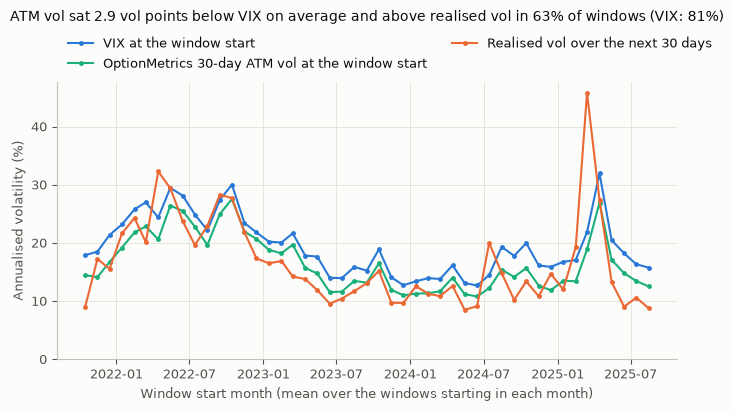

In [20]:
if om is not None:
    AQUA = "#1baf7a"  # third series colour after blue and orange
    dates_5c = start_dates[om_rows]
    share_5c = {label: np.mean(sig**2 * T0_5c > runs_5c[label].rv) for label, sig in sigma_5c.items()}
    gap_starts = sigma_5c["VIX"] - sigma_atm  # VIX minus ATM vol at the plotted window starts
    # Monthly means by window start month, so the chart shows no single day's OptionMetrics value.
    monthly = pd.DataFrame(
        {"VIX": sigma_5c["VIX"], "ATM": sigma_atm, "realised": sigma_r_5c}, index=dates_5c
    ).groupby(dates_5c.to_period("M")).mean()
    mid_month = monthly.index.to_timestamp() + pd.Timedelta(days=14)
    print(f"Figure 7b: monthly means over {len(monthly)} window start months, {monthly.index[0]} to {monthly.index[-1]}")
    print(f"Mean VIX minus ATM vol over the {dates_5c.size} window starts: {100 * gap_starts.mean():.2f} vol points")

    fig, ax = plt.subplots(figsize=(8, 3.6))
    for column, colour, label in (
        ("VIX", BLUE, "VIX at the window start"),
        ("ATM", AQUA, "OptionMetrics 30-day ATM vol at the window start"),
        ("realised", ORANGE, "Realised vol over the next 30 days"),
    ):
        ax.plot(mid_month, 100 * monthly[column], color=colour, lw=1.5, marker="o", ms=2.5, label=label)
    ax.set_xlabel("Window start month (mean over the windows starting in each month)")
    ax.set_ylabel("Annualised volatility (%)")
    ax.set_ylim(bottom=0)
    ax.set_title(
        f"ATM vol sat {100 * gap_starts.mean():.1f} vol points below VIX on average and above realised vol "
        f"in {share_5c['OptionMetrics ATM']:.0%} of windows (VIX: {share_5c['VIX']:.0%})",
        pad=44,
    )
    ax.legend(loc="lower left", bbox_to_anchor=(0.0, 1.0), ncol=2)
    save(fig, "fig7b_vix_atm_vs_realised_vol.png")
    plt.show()

## Stage 2b: Chain cleaning and implied forwards

Clean the option chain, fit parity forwards, and apply filters; produce Table 1.

The surface track starts from one SPY chain snapshot, cleaned as in DESIGN.md section 5. The expiries are the monthly expiry of each month (the third Friday, or the Thursday before it when that Friday is an exchange holiday) from 7 days out to 1 year, plus the quarterly and January (LEAPS) monthlies beyond. T runs from each expiry's own fetch time to the 16:00 New York close on the expiry date, in calendar days over 365.

The spot quote did not move during the pull, and Yahoo's option quotes are about 15 minutes old: the latest trade of every expiry comes at least 15 minutes before its fetch (printed below). The implied carry and the out-of-the-money selection therefore use the spot at the quote time, the close of the SPY 1-minute bar whose close falls nearest the latest option trade in the chain (spot_bar), from the day's bars frozen in data/frozen/. Yahoo labels a bar by its opening minute, so the bar labelled t closes at t + 1 minute. The bar nearest the first fetch is printed next to it. The fit bands keep the spot quote.

Forwards come from put-call parity, C - P = D·(F - K), fitted per expiry before any filtering. D is not fitted: it is exp(-r·T), with r the ^IRX rate of the last close before the snapshot. SPY options are American, and an in-the-money put carries an early-exercise premium that grows with the strike, so a free slope over strikes on both sides of the spot overstates D. F is therefore the weighted least squares fit with the slope held at -D, over the strikes from 5% below the spot up to the spot, where the put is out of the money, with weights 1/(h_C² + h_P²) from the half-spreads h. The free-slope fit over strikes within 5% on both sides is kept in the table as a diagnostic (D free and its implied rate r free): a D free above 1 is the early-exercise premium, not a negative rate. A second free-slope diagnostic uses only the one-sided band, from max(5%, 10%·√T) below the spot up to the spot, where the put is out of the money (r one-sided). No curve is fitted to these rates, and neither diagnostic is used downstream. Table 1b sets the flat ^IRX rate against the Treasury curve.

Parity holds within the market at a strike when the residual (C_mid - P_mid) - D·(F - K) lies within the combined half-spread h_C + h_P, the half-width of the synthetic C - P market. The table reports that share on the fit strikes and, separately, on the strikes up to 5% above the spot, which the fit leaves out.

The filters then apply in order to every contract of the selected expiries, and each removal is counted under the first rule it fails: zero bid; relative spread (ask - bid)/mid above 0.25; open interest below 10. Last, the in-the-money side is dropped against spot_bar, the spot at the quote time S_bar (puts with K ≥ S_bar, calls with K < S_bar), which leaves out-of-the-money quotes; their log-moneyness is still k = ln(K/F). The boundary is the spot, not F: a put with S_bar ≤ K < F is in the money against the spot, so its early-exercise premium inflates its implied vol, while the call at the same strike is out of the money. Stage 2c measures the effect on the smile. The cleaned chain is frozen in data/frozen/ with every contract's status, so this section runs without the raw snapshot. Implied vols and total variance w = σ²T follow in Stage 2c.

In [21]:
import json

from volsurf.data import (
    chain_summary, clean_chain, interp_rate, load_chain, load_treasury_curve, snapshot_spot_bar, treasury_rates,
)

SNAPSHOT = ROOT / "data" / "raw" / "spy_chain_20260930T192047Z.parquet"  # primary snapshot: switch it here

chain = load_chain(SNAPSHOT)  # reads the frozen cleaned chain; cleans the raw snapshot only if that is missing
spots = snapshot_spot_bar(SNAPSHOT)  # matches the frozen 1-minute bars of the snapshot day
manifest = json.loads((ROOT / "data" / "frozen" / "manifest.json").read_text())
frozen_name, chain_entry = next((name, e) for name, e in manifest["chains"].items() if e["snapshot"] == SNAPSHOT.name)
fetch = chain["fetch_utc"]
spot, rate = chain["spot_start"].iloc[0], chain["rate"].iloc[0]
spot_bar = spots["spot_bar"]["close"]  # spot at the quote time, used for the implied carry
expiries = chain["expiry"].drop_duplicates()
by_expiry = chain.groupby("expiry")
lag = (by_expiry["fetch_utc"].first() - by_expiry["lastTradeDate"].max()).dt.total_seconds() / 60  # minutes
print(f"Snapshot {SNAPSHOT.name}, cleaned chain data/frozen/{frozen_name}")
print(
    f"Selected expiries fetched {fetch.min():%Y-%m-%d %H:%M:%S} to {fetch.max():%H:%M:%S} UTC "
    f"({fetch.min().tz_convert('America/New_York'):%H:%M} New York)"
)
print(
    f"Latest option trade {chain['lastTradeDate'].max():%H:%M:%S} UTC; per expiry the latest trade precedes the fetch by "
    f"{lag.min():.1f} to {lag.max():.1f} minutes (at least 15 minutes on every expiry: {bool((lag >= 15).all())})"
)
print(
    f"Spot quote S = {spot:.2f} at the start and {chain['spot_end'].iloc[0]:.2f} at the end of the pull "
    f"(unchanged: {bool(chain['spot_start'].iloc[0] == chain['spot_end'].iloc[0])}); the fit bands use it"
)
for label, key in [("the latest option trade, used for the carry", "spot_bar"), ("the first fetch", "spot_bar_fetch")]:
    bar = spots[key]
    start, end, target = (pd.Timestamp(bar[k]) for k in ["bar_start", "bar_end", "target_utc"])
    print(f"1-minute bar nearest {label} ({target:%H:%M:%S} UTC): close {bar['close']:.2f}, bar {start:%H:%M} to {end:%H:%M} UTC")
print(
    f"r = {100 * rate:.3f}% continuously compounded, from the ^IRX close of "
    f"{chain_entry['rate_date']}, for every expiry"
)
print(f"{chain_entry['raw_rows']} contracts in the snapshot, {len(chain)} in the {expiries.size} selected expiries:")
print(", ".join(f"{e:%Y-%m-%d}" for e in expiries))

Snapshot spy_chain_20260930T192047Z.parquet, cleaned chain data/frozen/chain_20260930.parquet
Selected expiries fetched 2026-09-30 19:20:52 to 19:21:04 UTC (15:20 New York)
Latest option trade 19:05:42 UTC; per expiry the latest trade precedes the fetch by 15.2 to 44.7 minutes (at least 15 minutes on every expiry: True)
Spot quote S = 766.48 at the start and 766.48 at the end of the pull (unchanged: True); the fit bands use it
1-minute bar nearest the latest option trade, used for the carry (19:05:42 UTC): close 766.70, bar 19:05 to 19:06 UTC
1-minute bar nearest the first fetch (19:20:47 UTC): close 766.57, bar 19:20 to 19:21 UTC
r = 4.143% continuously compounded, from the ^IRX close of 2026-09-29, for every expiry
9815 contracts in the snapshot, 4625 in the 12 selected expiries:
2026-10-16, 2026-11-20, 2026-12-18, 2027-01-15, 2027-03-19, 2027-06-17, 2027-09-17, 2027-12-17, 2028-01-21, 2028-06-16, 2028-12-15, 2029-01-19


## Table 1: forwards and parity
Table 1 has one row per selected expiry, in two parts. The forwards part is below: the valid pairs in the fit, F, D = exp(-r·T) and the rate r used, the implied carry q = r - ln(F/S)/T with S = spot_bar, the spot at the quote time, the share of fit pairs whose parity residual lies within the combined half-spread, the same share on the pairs up to 5% above the spot, and two free-slope diagnostics: D free with r free = -ln(D free)/T over the strikes within 5% on both sides, and r one-sided = -ln(D)/T over the one-sided band, with its pair count. The contracts part (removals per rule, contracts kept and strike range) is in Stage 2c, after the no-IV filter adds the last rule; the totals line below counts the removals under the Stage 2b rules.

In [22]:
table_1 = chain_summary(chain, spot=spot_bar)  # the carry at the spot of the quote time
table_1.index = table_1.index.strftime("%Y-%m-%d")
removals = ["zero_bid", "spread", "open_interest", "in_the_money"]


def percent(share):
    """A share as a whole percentage, kept missing where the share is."""
    return (100 * share).round().astype("Int64")


forwards_1 = pd.DataFrame({
    "pairs": table_1["pairs"],
    "F": table_1["F"].round(2),
    "D": table_1["D"].round(6),
    "r (%)": (100 * table_1["rate"]).round(3),
    "q (%)": (100 * table_1["q"]).round(2),
    "within (%)": percent(table_1["within"]),
    "pairs above S": table_1["pairs_upper"],
    "within above S (%)": percent(table_1["within_upper"]),
    "D free": table_1["D_free"].round(6),
    "r free (%)": (100 * table_1["r_free"]).round(2),
    "pairs one-sided": table_1["pairs_one_sided"],
    "r one-sided (%)": (100 * table_1["r_one_sided"]).round(2),
})
print("Table 1, forwards and parity:")
display(forwards_1)

totals = table_1[["contracts", *removals, "kept_puts", "kept_calls", "kept"]].sum()
print(
    f"Totals under the Stage 2b rules: {totals['contracts']} contracts; removed {totals['zero_bid']} for a zero bid, "
    f"{totals['spread']} for the spread, {totals['open_interest']} for open interest and "
    f"{totals['in_the_money']} in the money; kept {totals['kept']} ({totals['kept_puts']} puts, "
    f"{totals['kept_calls']} calls)"
)
for label, pairs, share in [("fit pairs", "pairs", "within"), ("pairs above the spot", "pairs_upper", "within_upper")]:
    n = table_1[pairs].sum()
    print(f"Parity within the combined half-spread: {(table_1[pairs] * table_1[share]).sum() / n:.0%} of {n} {label}")
print(f"D free above 1 on {(table_1['D_free'] > 1).sum()} of {len(table_1)} expiries")

Table 1, forwards and parity:


,pairs,F,D,r (%),q (%),within (%),pairs above S,within above S (%),D free,r free (%),pairs one-sided,r one-sided (%)
expiry,,,,,,,,,,,,
2026-10-16,37,768.21,0.998183,4.143,-0.33,95,38,45,1.007878,-17.87,37,-7.90
2026-11-20,29,771.33,0.994220,4.143,-0.16,79,26,0,1.011687,-8.30,29,-1.64
2026-12-18,15,773.08,0.991066,4.143,0.31,40,24,0,1.016180,-7.41,15,-2.55
2027-01-15,8,774.85,0.987921,4.143,0.54,38,8,0,1.013661,-4.63,8,-0.27
2027-03-19,8,780.44,0.980887,4.143,0.33,25,8,0,1.016944,-3.61,10,0.10
2027-06-17,8,787.98,0.970918,4.143,0.30,50,8,0,1.015199,-2.12,13,1.24
2027-09-17,8,795.89,0.960832,4.143,0.27,75,8,0,1.018316,-1.88,15,0.82
2027-12-17,8,804.19,0.950955,4.143,0.21,100,8,38,1.017784,-1.45,16,2.85
2028-01-21,8,806.51,0.947185,4.143,0.28,100,8,50,1.000972,-0.07,17,2.73


Totals under the Stage 2b rules: 4625 contracts; removed 365 for a zero bid, 252 for the spread, 629 for open interest and 1132 in the money; kept 2247 (1374 puts, 873 calls)
Parity within the combined half-spread: 78% of 153 fit pairs
Parity within the combined half-spread: 25% of 159 pairs above the spot
D free above 1 on 9 of 12 expiries


## Table 1b: the ^IRX rate against the Treasury curve
The flat ^IRX rate prices every expiry at a 13-week bill rate. The term-structure alternative is the Treasury constant-maturity curve from FRED (DGS1MO, DGS3MO, DGS6MO, DGS1, DGS2 and DGS3) on the snapshot date, or the latest earlier date when that day is not yet published, frozen in data/frozen/. Each yield y is a semiannual bond-equivalent yield, so r = 2·ln(1 + y/2). r(T) is linear in T between the tenors and flat below 1 month and beyond 3 years, and the 2-year and 3-year par yields are used as zero rates. With D = exp(-r(T)·T), F is refitted with the slope held at -D on the same strikes, and the filters and the out-of-the-money selection are rerun. The selection is set by spot_bar, not F, so the kept set cannot change with the rate. The table sets the rates, forwards, parity shares and implied carry of the two choices side by side, with the one-sided implied rate as a diagnostic.

The Treasury curve becomes the default D only if the implied carry of every expiry after 2026-12-18 lies within 0.8% to 1.6% a year; otherwise the flat ^IRX rate stays the default. On this snapshot the rule fails: the Treasury-curve carry after 2026-12-18 runs from 0.48% to 0.85% and lies in the band on 1 of the 9 expiries, so the flat ^IRX rate stays the default D and the frozen chain is unchanged.

In [23]:
CARRY_AFTER, CARRY_BAND = "2026-12-18", (0.008, 0.016)  # Treasury default only if every q after the cutoff is in the band

snapshot_date = fetch.min().tz_convert("America/New_York").tz_localize(None).normalize()
curve = load_treasury_curve(snapshot_date)  # reads data/frozen/ust_curve_YYYYMMDD.csv
curve_date, tenors, ust_rates = treasury_rates(curve, snapshot_date)


def treasury_rate(T):
    """Treasury rate r(T): linear in T between the CMT tenors, flat beyond them."""
    return interp_rate(T, tenors, ust_rates)


print(f"Treasury curve of {curve_date:%Y-%m-%d}, the latest complete FRED date on or before {snapshot_date:%Y-%m-%d}:")
display(pd.DataFrame(
    {
        "tenor (months)": np.round(12 * tenors).astype(int),
        "yield (%)": curve.loc[curve_date].to_numpy(),
        "r (%)": (100 * ust_rates).round(3),
    },
    index=curve.columns,
))

chain_ust = clean_chain(chain, treasury_rate, spot_bar)  # re-cleans the frozen quotes; every derived column is recomputed
table_ust = chain_summary(chain_ust, spot=spot_bar)
table_ust.index = table_ust.index.strftime("%Y-%m-%d")
rate_choices = {"^IRX": table_1, "Treasury": table_ust}


def side_by_side(column, scale=1, digits=2):
    """One Table 1 column under both rate choices."""
    return pd.DataFrame({name: (scale * t[column]).round(digits) for name, t in rate_choices.items()})


table_1b = pd.concat({
    "r (%)": side_by_side("rate", 100, 3).assign(**{"one-sided": (100 * table_1["r_one_sided"]).round(2)}),
    "F": side_by_side("F"),
    "within (%)": pd.DataFrame({name: percent(t["within"]) for name, t in rate_choices.items()}),
    "within above S (%)": pd.DataFrame({name: percent(t["within_upper"]) for name, t in rate_choices.items()}),
    "q (%)": side_by_side("q", 100),
}, axis=1)
print("Table 1b, forwards, parity and carry under the flat ^IRX rate and the Treasury curve:")
display(table_1b)
kept_irx, kept_ust = ((c["status"] == "kept").sum() for c in (chain, chain_ust))
print(f"Contracts kept: {kept_irx} under the ^IRX rate, {kept_ust} under the Treasury curve")

late = table_ust.index > CARRY_AFTER
q_late = table_ust.loc[late, "q"]
in_band = q_late.between(*CARRY_BAND)
print(
    f"Treasury-curve carry after {CARRY_AFTER}: {100 * q_late.min():.2f}% to {100 * q_late.max():.2f}%, within "
    f"{100 * CARRY_BAND[0]:.1f}% to {100 * CARRY_BAND[1]:.1f}% on {in_band.sum()} of {late.sum()} expiries"
)
if in_band.all():
    print("Default D: the Treasury curve, because the carry of every expiry after the cutoff lies in the band")
else:
    print(
        f"Default D: the flat ^IRX rate, because the Treasury-curve carry lies outside the band on "
        f"{(~in_band).sum()} of those expiries"
    )

Treasury curve of 2026-09-29, the latest complete FRED date on or before 2026-09-30:


,tenor (months),yield (%),r (%)
DGS1MO,1,4.04,4.000
DGS3MO,3,4.25,4.205
DGS6MO,6,4.36,4.313
DGS1,12,4.58,4.528
DGS2,24,4.89,4.831
DGS3,36,4.98,4.919


Table 1b, forwards, parity and carry under the flat ^IRX rate and the Treasury curve:


r (%)                          F          within (%)           \
             ^IRX Treasury one-sided    ^IRX Treasury       ^IRX Treasury   
expiry                                                                      
2026-10-16  4.143    4.000     -7.90  768.21   768.21         95       95   
2026-11-20  4.143    4.070     -1.64  771.33   771.33         79       83   
2026-12-18  4.143    4.164     -2.55  773.08   773.09         40       40   
2027-01-15  4.143    4.224     -0.27  774.85   774.86         38       38   
2027-03-19  4.143    4.298      0.10  780.44   780.46         25       25   
2027-06-17  4.143    4.405      1.24  787.98   788.05         50       38   
2027-09-17  4.143    4.513      0.82  795.89   796.01         75       75   
2027-12-17  4.143    4.593      2.85  804.19   804.50        100      100   
2028-01-21  4.143    4.622      2.73  806.51   806.86        100      100   
2028-06-16  4.143    4.744      2.34  820.68   821.44        100      100   
2028-12-15  4.143    4.850      2.93  837.59   839.02        100      100   
2029-01-19  4.143    4.858      3.19  839.50   841.02        100      100   

           within above S (%)          q (%)           
                         ^IRX Treasury  ^IRX Treasury  
expiry                                                 
2026-10-16                 45       45 -0.33    -0.47  
2026-11-20                  0        0 -0.16    -0.23  
2026-12-18                  0        0  0.31     0.34  
2027-01-15                  0        0  0.54     0.62  
2027-03-19                  0        0  0.33     0.48  
2027-06-17                  0        0  0.30     0.55  
2027-09-17                  0        0  0.27     0.62  
2027-12-17                 38       38  0.21     0.63  
2028-01-21                 50       50  0.28     0.72  
2028-06-16                 75       62  0.17     0.72  
2028-12-15                 25       12  0.14     0.77  
2029-01-19                100       71  0.21     0.85

Contracts kept: 2247 under the ^IRX rate, 2247 under the Treasury curve
Treasury-curve carry after 2026-12-18: 0.48% to 0.85%, within 0.8% to 1.6% on 1 of 9 expiries
Default D: the flat ^IRX rate, because the Treasury-curve carry lies outside the band on 8 of those expiries


## Stage 2c: Implied volatility extraction

Solve for implied vols via Brent's method; produce Figure 1.

## Brent against Newton on a deep out-of-the-money put
Implied vols come from Brent's method (scipy's brentq) on the bracket 0.001 ≤ σ ≤ 5.0 with xtol 1e-14, as in DESIGN.md section 6. The Black-76 price rises strictly with σ, so a root lies in the bracket exactly when the price at σ = 0.001 is below the quote and the price at σ = 5.0 above it, and the solver checks that sign change first. A price outside the strict no-arbitrage bounds, D·max(F - K, 0) < C < D·F for a call and D·max(K - F, 0) < P < D·K for a put, has no implied vol, and neither has a price whose root lies outside the bracket: both return NaN.

Newton's method is the obvious alternative, and it fails where a surface needs the solver most, deep out of the money. The example is the DESIGN.md put: F = 100, K = 85, T = 14 days, D = 1, priced at σ = 0.40. From the common start σ0 = 0.20 the put's vega is almost zero, so the first step overshoots far past the root; there the put is worth almost D·K, and the second step lands on a negative vol. The Manaster-Koehler start σ0 = √(2|ln(F/K)|/T) is the vol at which vega peaks in σ, the inflection point of the price: the price is convex in σ below it and concave above it, so Newton's method converges monotonically from there. Brent's method needs neither a start nor a derivative: it keeps the root bracketed and never leaves the bracket, at the cost of more evaluations. Newton stops when a step moves σ by less than 1e-10, and fails at a vol that is not positive. The chart is a diagnostic only and is not saved to figures/.

Put with F = 100, K = 85, T = 14 days, D = 1, priced at sigma = 0.40: 0.05007364
Naive Newton from 0.20: iterate 1 = 38.243449, iterate 2 = -13054.718015; converged: False (it stops at a vol that is not positive)
Manaster-Koehler Newton from 2.911048: 8 steps, converged: True, monotone: True


,sigma,|sigma - 0.40|
step,,
0,2.9110,2.51e+00
1,0.8000,4.00e-01
2,0.5453,1.45e-01
3,0.4461,4.61e-02
4,0.4080,8.05e-03
5,0.4003,3.25e-04
6,0.4000,5.68e-07
7,0.4000,1.73e-12
8,0.4000,1.11e-16


Brent on [0.001, 5.0]: 17 iterations, 18 evaluations, |root - 0.40| = 3.3e-16; the same root as black76_implied_vol: True


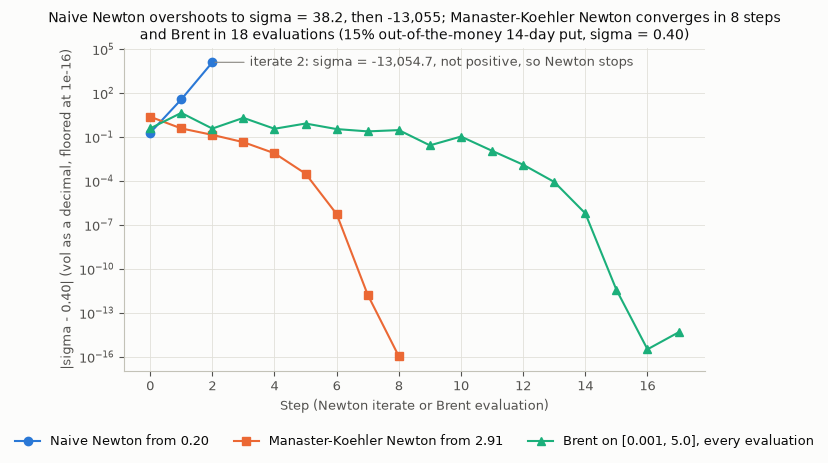

In [24]:
from matplotlib.ticker import MaxNLocator
from scipy.optimize import brentq

from volsurf.black_scholes import black76_price
from volsurf.implied_vol import black76_implied_vol, newton_manaster_koehler, newton_naive

DEMO = {"F": 100.0, "K": 85.0, "T": 14 / 365, "D": 1.0, "is_call": False}  # DESIGN.md section 6
DEMO_SIGMA, SIGMA_BRACKET, BRENT_XTOL = 0.40, (0.001, 5.0), 1e-14
ERROR_FLOOR = 1e-16  # plotted errors below this are drawn at it (machine precision)
AQUA = "#1baf7a"  # third categorical slot

demo_price = float(black76_price(**DEMO, sigma=DEMO_SIGMA))
naive, naive_converged = newton_naive(demo_price, **DEMO, sigma0=0.20)
mk, mk_converged = newton_manaster_koehler(demo_price, **DEMO)
brent_points = []  # every vol at which Brent prices the put


def demo_excess(sigma):
    """Black-76 price of the demo put at sigma minus its target price, recording sigma."""
    brent_points.append(sigma)
    return float(black76_price(**DEMO, sigma=sigma)) - demo_price


brent_root, brent = brentq(demo_excess, *SIGMA_BRACKET, xtol=BRENT_XTOL, full_output=True)
brent_points = np.array(brent_points)

print(
    f"Put with F = {DEMO['F']:.0f}, K = {DEMO['K']:.0f}, T = {365 * DEMO['T']:.0f} days, D = {DEMO['D']:.0f}, "
    f"priced at sigma = {DEMO_SIGMA:.2f}: {demo_price:.8f}"
)
print(
    f"Naive Newton from {naive[0]:.2f}: iterate 1 = {naive[1]:.6f}, iterate 2 = {naive[2]:.6f}; "
    f"converged: {naive_converged} (it stops at a vol that is not positive)"
)
print(
    f"Manaster-Koehler Newton from {mk[0]:.6f}: {mk.size - 1} steps, converged: {mk_converged}, "
    f"monotone: {bool(np.all(np.diff(mk) < 0))}"
)
display(pd.DataFrame(
    {"sigma": mk.round(4), "|sigma - 0.40|": [f"{e:.2e}" for e in np.abs(mk - DEMO_SIGMA)]},
    index=pd.RangeIndex(mk.size, name="step"),
))
print(
    f"Brent on [{SIGMA_BRACKET[0]}, {SIGMA_BRACKET[1]:.1f}]: {brent.iterations} iterations, {brent.function_calls} "
    f"evaluations, |root - 0.40| = {abs(brent_root - DEMO_SIGMA):.1e}; the same root as black76_implied_vol: "
    f"{bool(brent_root == black76_implied_vol(demo_price, **DEMO))}"
)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
series = [
    ("Naive Newton from 0.20", naive, BLUE, "o"),
    (f"Manaster-Koehler Newton from {mk[0]:.2f}", mk, ORANGE, "s"),
    ("Brent on [0.001, 5.0], every evaluation", brent_points, AQUA, "^"),
]
for label, sigmas, colour, marker in series:
    error = np.maximum(np.abs(sigmas - DEMO_SIGMA), ERROR_FLOOR)
    ax.semilogy(np.arange(sigmas.size), error, color=colour, marker=marker, ms=6, lw=1.5, label=label)
ax.annotate(
    f"iterate 2: sigma = {naive[2]:,.1f}, not positive, so Newton stops",
    xy=(2, abs(naive[2] - DEMO_SIGMA)), xytext=(3.2, abs(naive[2] - DEMO_SIGMA)),
    va="center", color=INK_2, arrowprops={"arrowstyle": "-", "color": MUTED, "lw": 0.8},
)
ax.set_xlabel("Step (Newton iterate or Brent evaluation)")
ax.set_ylabel("|sigma - 0.40| (vol as a decimal, floored at 1e-16)")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3)
ax.set_title(
    f"Naive Newton overshoots to sigma = {naive[1]:.1f}, then {naive[2]:,.0f}; Manaster-Koehler Newton converges "
    f"in {mk.size - 1} steps\nand Brent in {brent.function_calls} evaluations "
    f"(15% out-of-the-money 14-day put, sigma = {DEMO_SIGMA:.2f})"
)
plt.show()

## Implied vols and the no-IV filter
Every kept contract, an out-of-the-money put below S_bar or call at or above it, is solved at its bid-ask mid with its expiry's F, D and T. The no-IV filter is the last rule: a kept contract without an implied vol is relabelled 'no IV' in a copy of the chain, so the frozen file in data/frozen/ is unchanged. Total variance w = σ²T is computed on the same copy for the contracts that keep an implied vol; Stage 3 fits SVI to w against k.

## Table 1: contracts
One row per selected expiry: T in calendar days, the expiry's contracts in the snapshot, the removals under each rule in order (zero bid, spread, open interest, in the money, no IV), the contracts kept (puts and calls) and the strike range kept. The forwards part of Table 1 is in the Stage 2b section, and the last line below checks that the no-IV filter leaves it unchanged.

In [25]:
kept = chain["status"] == "kept"
kept_quotes = chain[kept]
chain_iv = chain.copy()  # the frozen chain stays as it is
chain_iv["iv"] = np.nan
chain_iv.loc[kept, "iv"] = black76_implied_vol(
    kept_quotes["mid"], kept_quotes["F"], kept_quotes["strike"], kept_quotes["T"], kept_quotes["D"],
    kept_quotes["option_type"] == "call",
)
no_iv = kept & chain_iv["iv"].isna()
chain_iv.loc[no_iv, "status"] = "no IV"
chain_iv["w"] = chain_iv["iv"] ** 2 * chain_iv["T"]  # total variance, NaN without an implied vol
surface = chain_iv[chain_iv["status"] == "kept"]  # the quotes Stage 3 fits
print(
    f"Solved {kept.sum()} kept contracts at the bid-ask mid: {len(surface)} with an implied vol, "
    f"{no_iv.sum()} without (no IV)"
)
print(f"Implied vols from {100 * surface['iv'].min():.2f}% to {100 * surface['iv'].max():.2f}%")

summary_iv = chain_summary(chain_iv, spot=spot_bar)
summary_iv.index = summary_iv.index.strftime("%Y-%m-%d")
rules_1 = ["zero_bid", "spread", "open_interest", "in_the_money", "no_IV"]
contracts_1 = summary_iv[["T_days", "contracts", *rules_1, "kept_puts", "kept_calls", "kept", "K_min", "K_max"]].rename(
    columns={
        "T_days": "T (days)", "zero_bid": "zero bid", "open_interest": "open interest",
        "in_the_money": "in the money", "no_IV": "no IV", "kept_puts": "kept puts", "kept_calls": "kept calls",
        "K_min": "K min", "K_max": "K max",
    }
)
print("Table 1, contracts:")
with pd.option_context("display.float_format", "{:.2f}".format):
    display(contracts_1)

totals_1 = summary_iv[["contracts", *rules_1, "kept_puts", "kept_calls", "kept"]].sum()
print(
    f"Totals: {totals_1['contracts']} contracts; removed {totals_1['zero_bid']} for a zero bid, {totals_1['spread']} "
    f"for the spread, {totals_1['open_interest']} for open interest, {totals_1['in_the_money']} in the money and "
    f"{totals_1['no_IV']} with no IV; kept {totals_1['kept']} ({totals_1['kept_puts']} puts, "
    f"{totals_1['kept_calls']} calls)"
)
forward_columns = ["pairs", "F", "D", "rate", "q", "within", "within_upper", "F_free", "D_free", "r_one_sided"]
print(
    "The no-IV filter leaves the forwards part of Table 1 unchanged: "
    f"{summary_iv[forward_columns].equals(table_1[forward_columns])}"
)

Solved 2247 kept contracts at the bid-ask mid: 2247 with an implied vol, 0 without (no IV)
Implied vols from 10.80% to 85.67%
Table 1, contracts:


,T (days),contracts,zero bid,spread,open interest,in the money,no IV,kept puts,kept calls,kept,K min,K max
expiry,,,,,,,,,,,,
2026-10-16,16.03,434,61,32,69,129,0,95,48,143,560.00,830.00
2026-11-20,51.07,366,8,28,54,88,0,135,53,188,360.00,895.00
2026-12-18,79.07,432,13,18,25,137,0,154,85,239,265.00,955.00
2027-01-15,107.07,414,63,30,43,118,0,114,46,160,200.00,1000.00
2027-03-19,170.03,336,32,20,40,85,0,103,56,159,250.00,1100.00
2027-06-17,260.03,394,33,25,38,95,0,129,74,203,95.00,1240.00
2027-09-17,352.03,376,25,14,64,69,0,121,83,204,90.00,1320.00
2027-12-17,443.07,413,36,4,41,108,0,128,96,224,70.00,1480.00
2028-01-21,478.07,404,26,10,57,89,0,125,97,222,85.00,1440.00


Totals: 4625 contracts; removed 365 for a zero bid, 252 for the spread, 629 for open interest, 1132 in the money and 0 with no IV; kept 2247 (1374 puts, 873 calls)
The no-IV filter leaves the forwards part of Table 1 unchanged: True


## The put-to-call step: F against S_bar
Each smile switches from puts to calls at the out-of-the-money boundary. The first design set that boundary at the fitted forward F, keeping puts with K < F. SPY options are American, and F lies above the spot here, so the puts with S_bar ≤ K < F are in the money against the spot, and their early-exercise premium raises their implied vol above that of the call at the same strike. The frozen chain now sets the boundary at S_bar, the spot at the quote time, so that both sides of the switch are out of the money against the spot.

The table compares the two boundaries on the same quotes: every contract of the frozen chain that passes the three quote filters, selected once with K < F for puts and K ≥ F for calls, and once with K < S_bar and K ≥ S_bar, then solved at its mid as above. The step is the implied vol of the first call at or above the boundary minus that of the last put below it, the strikes either side are shown, and quotes without an implied vol are left out. Adjacent strikes are 1 to 5 apart, so a small part of each step is the slope of the smile between them.


In [26]:
def switch_gap(rows):
    """IV of the first call minus IV of the last put, where one expiry's smile switches from puts to calls.

    rows holds one expiry's out-of-the-money quotes with an implied vol, puts below the boundary and calls at
    or above it.
    """
    is_call = rows["option_type"] == "call"
    return rows.loc[is_call].sort_values("strike")["iv"].iloc[0] - rows.loc[~is_call].sort_values("strike")["iv"].iloc[-1]


passed = chain["status"].isin(["kept", "in the money"])  # every quote filter passed
call_side = chain["option_type"] == "call"
otm_rules = {
    "F": passed & pd.Series(np.where(call_side, chain["strike"] >= chain["F"], chain["strike"] < chain["F"]), chain.index),
    "S_bar": passed & pd.Series(np.where(call_side, chain["strike"] >= spot_bar, chain["strike"] < spot_bar), chain.index),
}
either = otm_rules["F"] | otm_rules["S_bar"]
step_quotes = chain[either].copy()
step_quotes["iv"] = black76_implied_vol(
    step_quotes["mid"], step_quotes["F"], step_quotes["strike"], step_quotes["T"], step_quotes["D"],
    step_quotes["option_type"] == "call",
)
step_rows = []
for expiry, g in step_quotes.groupby("expiry"):
    row = {"T (days)": 365 * g["T"].iloc[0], "F": g["F"].iloc[0]}
    for name, rule in otm_rules.items():
        side = g[rule[g.index] & g["iv"].notna()]
        is_call = side["option_type"] == "call"
        row[f"put K, {name}"] = side.loc[~is_call, "strike"].max()
        row[f"call K, {name}"] = side.loc[is_call, "strike"].min()
        row[f"step at {name} (vol points)"] = 100 * switch_gap(side)
    row["contracts switched"] = int((otm_rules["F"] != otm_rules["S_bar"])[g.index].sum())
    step_rows.append(row)
step_table = pd.DataFrame(step_rows, index=pd.Index(step_quotes["expiry"].drop_duplicates().dt.strftime("%Y-%m-%d"), name="expiry"))
print(
    f"Quotes passing every filter: {otm_rules['F'].sum()} out of the money with the boundary at F, "
    f"{otm_rules['S_bar'].sum()} with the boundary at S_bar = {spot_bar:.2f}; "
    f"{(otm_rules['F'] != otm_rules['S_bar']).sum()} contracts change side"
)
print(f"The frozen chain keeps exactly the S_bar selection: {bool((chain['status'] == 'kept').equals(otm_rules['S_bar']))}")
print("Call minus put implied vol where the smile switches sides, with the boundary at F and at S_bar:")
with pd.option_context("display.float_format", "{:.2f}".format):
    display(step_table)
step_F, step_S = step_table["step at F (vol points)"], step_table["step at S_bar (vol points)"]
T_days = step_table["T (days)"]
print(
    f"Step at F: {step_F.min():.2f} to {step_F.max():.2f} vol points; at S_bar: {step_S.min():.2f} to "
    f"{step_S.max():.2f} vol points; smaller in size at S_bar on every expiry: {bool((step_S.abs() < step_F.abs()).all())}"
)
print(
    f"Rank correlation of the step size with T: {step_F.abs().corr(T_days, method='spearman'):.2f} at F, "
    f"{step_S.abs().corr(T_days, method='spearman'):.2f} at S_bar"
)


Quotes passing every filter: 2245 out of the money with the boundary at F, 2247 with the boundary at S_bar = 766.70; 152 contracts change side
The frozen chain keeps exactly the S_bar selection: True
Call minus put implied vol where the smile switches sides, with the boundary at F and at S_bar:


,T (days),F,"put K, F","call K, F",step at F (vol points),"put K, S_bar","call K, S_bar",step at S_bar (vol points),contracts switched
expiry,,,,,,,,,
2026-10-16,16.03,768.21,768.00,769.00,-0.28,766.00,767.00,-0.17,4
2026-11-20,51.07,771.33,771.00,772.00,-0.30,766.00,767.00,-0.19,10
2026-12-18,79.07,773.08,773.00,774.00,-0.31,766.00,767.00,-0.20,14
2027-01-15,107.07,774.85,770.00,775.00,-0.57,765.00,770.00,-0.50,2
2027-03-19,170.03,780.44,780.00,785.00,-0.69,765.00,770.00,-0.45,6
2027-06-17,260.03,787.98,785.00,790.00,-0.72,765.00,770.00,-0.40,8
2027-09-17,352.03,795.89,795.00,800.00,-0.77,765.00,770.00,-0.27,12
2027-12-17,443.07,804.19,800.00,805.00,-0.97,765.00,770.00,-0.34,14
2028-01-21,478.07,806.51,805.00,810.00,-0.99,765.00,770.00,-0.34,16


Step at F: -1.86 to -0.28 vol points; at S_bar: -0.50 to -0.17 vol points; smaller in size at S_bar on every expiry: True
Rank correlation of the step size with T: 0.99 at F, 0.36 at S_bar


## Figure 1: raw smiles
Implied vol (%) against k = ln(K/F), one series per expiry, from the kept quotes (puts below S_bar, calls at or above it), coloured light to dark with T. The left panel shows every kept quote. The long expiries list strikes far into the wings, so the right panel zooms in on -0.5 ≤ k ≤ 0.3, on its own vertical scale.

The table reads each expiry's at-the-money vol and 10% out-of-the-money put vol off the raw quotes, linearly in k between the neighbouring kept strikes, at k = 0 and at k = ln 0.9 (K = 0.9·F). F lies above S_bar, so k = 0 falls among the calls. The column "call - put at S_bar" is the implied vol of the first call at or above S_bar minus that of the last put below it, the step in the smile where it switches from puts to calls (the S_bar column of the table above). These raw values carry the noise of the mids; Stage 3 replaces them with SVI fits.

Raw smiles: ATM vol at k = 0 and 10% out-of-the-money put vol at k = ln 0.9, linear in k between kept strikes


,T (days),IVs,k min,k max,ATM IV (%),10% OTM put IV (%),call - put at S_bar (vol points),put - ATM (vol points)
expiry,,,,,,,,
2026-10-16,16.03,143,-0.32,0.08,12.50,25.38,-0.17,12.88
2026-11-20,51.07,188,-0.76,0.15,13.61,21.67,-0.19,8.06
2026-12-18,79.07,239,-1.07,0.21,13.93,20.85,-0.20,6.91
2027-01-15,107.07,160,-1.35,0.26,14.05,20.17,-0.50,6.11
2027-03-19,170.03,159,-1.14,0.34,14.86,19.69,-0.45,4.83
2027-06-17,260.03,203,-2.12,0.45,15.81,19.69,-0.40,3.88
2027-09-17,352.03,204,-2.18,0.51,16.60,19.84,-0.27,3.24
2027-12-17,443.07,224,-2.44,0.61,16.97,19.92,-0.34,2.95
2028-01-21,478.07,222,-2.25,0.58,17.11,19.89,-0.34,2.78


10% OTM put vol above ATM vol on every expiry: True; by 2.36 to 12.88 vol points. ATM vol from 12.50% to 17.97%
Call minus put IV where the smile switches sides at S_bar: -0.50 to -0.17 vol points


Saved figures/fig1_raw_smiles.png


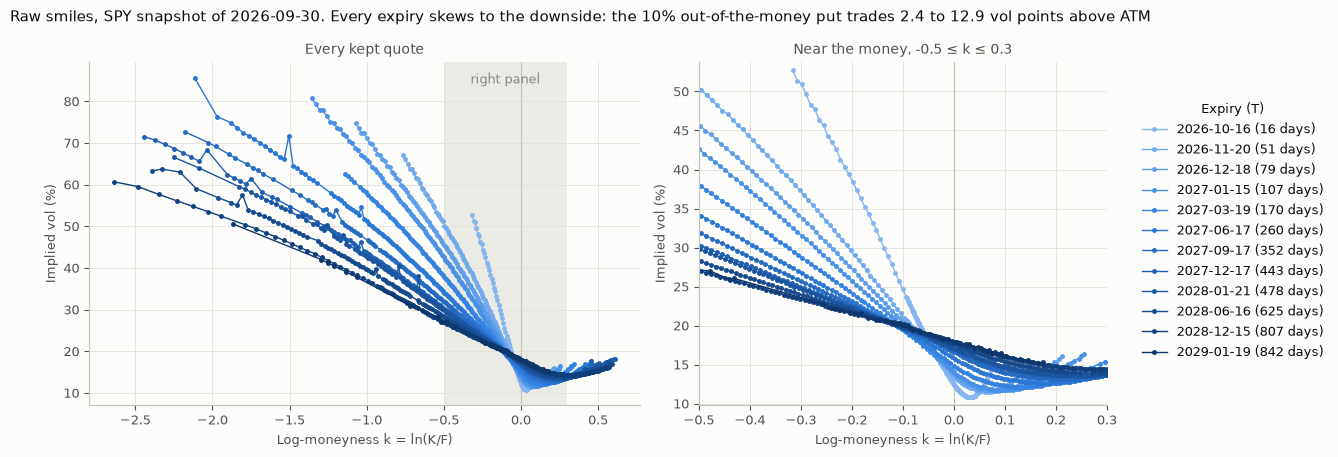

In [27]:
from matplotlib.colors import LinearSegmentedColormap

K_PUT_10 = np.log(0.9)  # 10% out-of-the-money put, K = 0.9·F
ZOOM = (-0.5, 0.3)  # k range of the right panel
# Blue ramp, steps 250 to 700: one hue, light to dark with T (the lightest step still clears 2:1 on the surface).
EXPIRY_RAMP = LinearSegmentedColormap.from_list(
    "blue_250_700",
    ["#86b6ef", "#6da7ec", "#5598e7", "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"],
)


def smile_at(rows, k):
    """Raw implied vol at log-moneyness k, linear in k between the neighbouring kept strikes (NaN outside them).

    rows holds one expiry's kept quotes sorted by k.
    """
    return float(np.interp(k, rows["k"], rows["iv"], left=np.nan, right=np.nan))


slices = [(expiry, rows.sort_values("k")) for expiry, rows in surface.groupby("expiry")]
smile_table = pd.DataFrame(
    [
        {
            "T (days)": 365 * rows["T"].iloc[0],
            "IVs": len(rows),
            "k min": rows["k"].iloc[0],
            "k max": rows["k"].iloc[-1],
            "ATM IV (%)": 100 * smile_at(rows, 0.0),
            "10% OTM put IV (%)": 100 * smile_at(rows, K_PUT_10),
            "call - put at S_bar (vol points)": 100 * switch_gap(rows),
        }
        for _, rows in slices
    ],
    index=pd.Index([f"{expiry:%Y-%m-%d}" for expiry, _ in slices], name="expiry"),
)
skew = smile_table["10% OTM put IV (%)"] - smile_table["ATM IV (%)"]
smile_table["put - ATM (vol points)"] = skew
print("Raw smiles: ATM vol at k = 0 and 10% out-of-the-money put vol at k = ln 0.9, linear in k between kept strikes")
with pd.option_context("display.float_format", "{:.2f}".format):
    display(smile_table)
put_above = bool((skew > 0).all())
switch = smile_table["call - put at S_bar (vol points)"]
print(
    f"10% OTM put vol above ATM vol on every expiry: {put_above}; by {skew.min():.2f} to {skew.max():.2f} vol points. "
    f"ATM vol from {smile_table['ATM IV (%)'].min():.2f}% to {smile_table['ATM IV (%)'].max():.2f}%"
)
print(f"Call minus put IV where the smile switches sides at S_bar: {switch.min():.2f} to {switch.max():.2f} vol points")

colours = EXPIRY_RAMP(np.linspace(0, 1, len(slices)))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), gridspec_kw={"width_ratios": [1.35, 1]})
for colour, (expiry, rows) in zip(colours, slices):
    label = f"{expiry:%Y-%m-%d} ({365 * rows['T'].iloc[0]:.0f} days)"
    for ax in axes:
        ax.plot(rows["k"], 100 * rows["iv"], color=colour, lw=1, marker="o", ms=2.5, label=label)
axes[0].axvspan(*ZOOM, color=GRID, alpha=0.6, lw=0, zorder=0)
axes[0].text(np.mean(ZOOM), 0.97, "right panel", transform=axes[0].get_xaxis_transform(), ha="center", va="top",
             color=MUTED)
near = surface[surface["k"].between(*ZOOM)]
axes[1].set_xlim(*ZOOM)
axes[1].set_ylim(100 * near["iv"].min() - 1, 100 * near["iv"].max() + 1)  # its own scale, so the zoom resolves
for ax, title in zip(axes, ["Every kept quote", f"Near the money, {ZOOM[0]} ≤ k ≤ {ZOOM[1]}"]):
    ax.axvline(0, color=AXIS, lw=0.8, zorder=1)
    ax.set_xlabel("Log-moneyness k = ln(K/F)")
    ax.set_ylabel("Implied vol (%)")
    ax.set_title(title, color=INK_2)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), title="Expiry (T)")
if put_above:
    finding = (
        f"Every expiry skews to the downside: the 10% out-of-the-money put trades {skew.min():.1f} to "
        f"{skew.max():.1f} vol points above ATM"
    )
else:
    finding = f"10% out-of-the-money put vol minus ATM vol runs from {skew.min():.1f} to {skew.max():.1f} vol points"
fig.suptitle(f"Raw smiles, SPY snapshot of {fetch.min():%Y-%m-%d}. {finding}")
fig.tight_layout()
save(fig, "fig1_raw_smiles.png")
plt.show()

## Stage 3: SVI calibration

Fit SVI smiles to each expiry slice; produce Figure 2 and Table 2.

## Stage 4: Arbitrage checks and variance-swap bridge

Check butterfly and calendar arbitrage, refit if needed, and build the variance-swap bridge; produce Figures 3 to 5 and Table 3.

## Stage 6: Write-up and reproducibility

Finalise README, verify fresh-install reproducibility, and tag v1.0.